In [1]:

%matplotlib inline 
from os import listdir
from os.path import isfile, join
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import math
import gensim
from itertools import repeat
import gensim.downloader
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.api as sm
# from gensim.models.fasttext import load_facebook_mode
import warnings
warnings.filterwarnings('ignore')


In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
tmp = pd.read_csv('../../data/kind.csv')

In [4]:
def make_ratings_mat(grouped_ratings_df):
    
    mat = np.zeros((len(np.unique(grouped_ratings_df.prompt)),71))
    for i,con in enumerate(np.unique(grouped_ratings_df.prompt)):
        ds = grouped_ratings_df[grouped_ratings_df.prompt==con]
        mat[i,:] = ds.iloc[:,3].values


    mat = pd.DataFrame(mat, index =np.unique(grouped_ratings_df.prompt), columns = np.arange(mat.shape[1]) )
    cmeans = mat.mean().values
    return mat, cmeans

In [5]:
uw71coords = pd.read_csv('../../data/UW71coordinates_long.csv')

In [6]:
concept2cat_dict = {'dress':'clothes','pants':'clothes','shirt':'clothes','shoes':'clothes','socks':'clothes',
                    'above':'directions','below':'directions','beside':'directions','far':'directions','near':'directions',
                    'angry':'emotions','happy':'emotions','sad':'emotions','fearful':'emotions','disgust':'emotions',
                    'blueberry':'fruits','mango':'fruits','lemon':'fruits','strawberry':'fruits','watermelon':'fruits',
                    'beach':'scenes','field':'scenes','ocean':'scenes','sky':'scenes','sunset':'scenes',
                    'day':'times-of-day','dawn':'times-of-day','dusk':'times-of-day','night':'times-of-day','noon':'times-of-day',
                    }


In [7]:
set_1_raw = pd.read_csv('../../data/uw71_set1_redo_raw.csv')
set1_grouped = set_1_raw.groupby(['concept','prompt','color_index']).response.agg(mean_rating = 'mean', se ='sem').reset_index()
ratings,ratings_cmeans= make_ratings_mat(set1_grouped)
concept_list = set1_grouped.pivot(index=['prompt','concept'], columns='color_index', values='mean_rating').reset_index().sort_values(by=['concept','prompt']).reset_index(drop=True)['prompt'].values
concept_list.sort()
concept_order  = {concept: i for i, concept in enumerate(concept_list)}
# ratings = pd.read_csv('../../data/uw71_set1_redo_raw.csv')
# ratings= ratings.rename(columns={"Unnamed: 0": "concepts"})

In [8]:
ratings = ratings.reset_index()
ratings = ratings.rename(columns={"index": "concepts"})
## sort the column concepts in ratings by the order of concept_list


In [9]:
ratings = ratings.sort_values(by=['concepts'], key=lambda x: x.map(concept_order)).reset_index(drop=True)

In [10]:
assocs = pd.read_csv('../../data/recon_assocs/gpt4_ratings.csv')
assocs_anchored = pd.read_csv('../../data/recon_assocs/gpt4_ratings_anchored.csv')
assocs_above = pd.read_csv('../../data/recon_assocs/gpt4_ratings_above.csv')
assocs_near = pd.read_csv('../../data/recon_assocs/gpt4_ratings_near.csv')


In [11]:
# plt.bar(np.arange(71),np.mean(assocs_justice.iloc[0:3,1:],axis=0), color = uw71coords.color_hex.values)
# plt.ylim([0,1])
# plt.title('GPT4 Color-Concept Associations Anchored Multiple')
# np.corrcoef(np.mean(assocs_justice.iloc[0:3,1:], axis=0).astype(float),np.array(ratings)[41,1:].astype(float))

array([[1.       , 0.6891734],
       [0.6891734, 1.       ]])

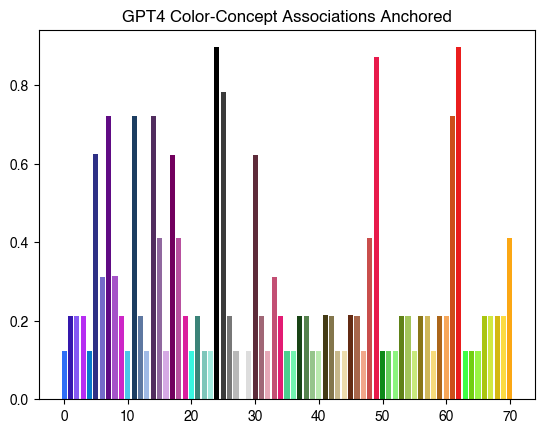

In [12]:

plt.bar(np.arange(71),np.array(assocs_anchored[assocs_anchored['Unnamed: 0']=='fearful'].iloc[:,1:])[0], color = uw71coords.color_hex.values)

# plt.ylim([0,1])
plt.title('GPT4 Color-Concept Associations Anchored')
np.corrcoef(np.array(assocs_anchored[assocs_anchored['Unnamed: 0']=='fearful'].iloc[:,1:])[0],\
            ratings[ratings.concepts=='fearful'].iloc[:,1:].values[0].astype(float))

array([[1.        , 0.58075123],
       [0.58075123, 1.        ]])

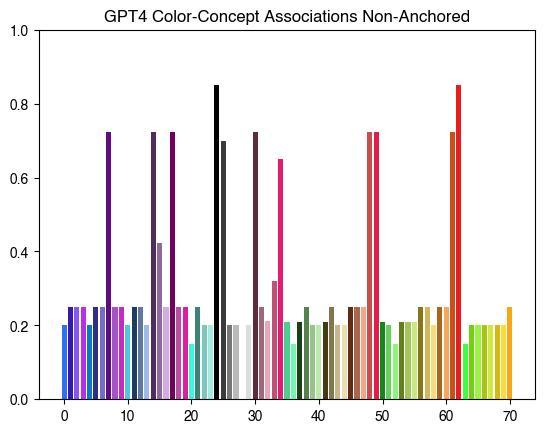

In [13]:

plt.bar(np.arange(71),np.array(assocs[assocs['Unnamed: 0']=='fearful'].iloc[:,1:])[0], color = uw71coords.color_hex.values)

plt.ylim([0,1])
plt.title('GPT4 Color-Concept Associations Non-Anchored')
np.corrcoef(np.array(assocs[assocs['Unnamed: 0']=='fearful'].iloc[:,1:])[0],\
            ratings[ratings.concepts=='fearful'].iloc[:,1:].values[0].astype(float))

Text(0.5, 1.0, 'Human Color-Concept Associations')

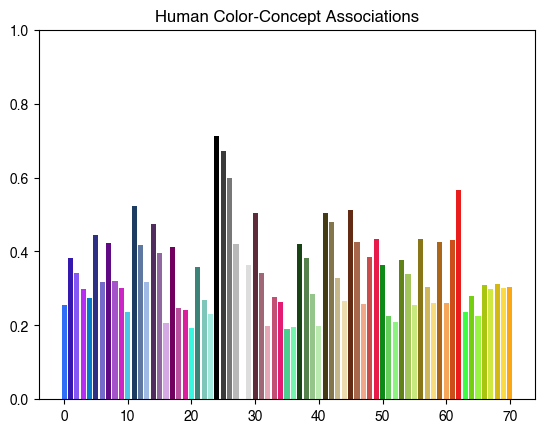

In [14]:
plt.bar(np.arange(71),ratings[ratings.concepts=='fearful'].iloc[:,1:].values[0].astype(float),\
         color = uw71coords.color_hex.values)
plt.ylim([0,1])
plt.title('Human Color-Concept Associations')

In [15]:
##what word embedding models are available?
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [16]:
# w2v_vecs = gensim.downloader.load('word2vec-google-news-300')
# ft_vecs = gensim.downloader.load('fasttext-wiki-news-subwords-300')

In [17]:
w2v_vecs = gensim.models.KeyedVectors.load_word2vec_format('/Users/kushinm/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz', binary=True)##replace with your path

In [18]:
#gensim.models.fasttext.load_facebook_model('/Users/kushin/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz')


In [19]:
gpt_embeds = pd.read_csv('../../data/gpt3embeddings.csv',index_col=0)

In [20]:
## Here's a 300 dim vector for a word

w2v_vecs['color']

array([-4.30297852e-03,  1.43554688e-01,  3.63769531e-02,  1.29882812e-01,
        1.27563477e-02, -1.92382812e-01,  3.06640625e-01, -2.49023438e-01,
        4.51660156e-02,  7.27539062e-02,  1.31835938e-01, -4.68750000e-02,
       -4.85839844e-02, -7.56835938e-02, -2.19726562e-03, -1.20117188e-01,
       -2.27539062e-01,  3.98437500e-01, -7.37304688e-02, -6.64062500e-01,
       -4.04296875e-01,  2.11181641e-02,  3.41796875e-02, -1.36718750e-01,
       -2.71484375e-01,  2.83203125e-02, -2.83203125e-01,  1.56250000e-01,
        1.20117188e-01, -6.83593750e-02, -4.04296875e-01,  2.14843750e-01,
       -4.15039062e-02,  1.24023438e-01, -9.03320312e-02,  5.49316406e-02,
        1.92871094e-02,  1.97753906e-02, -1.57226562e-01,  2.00195312e-02,
        1.52343750e-01, -3.61328125e-02,  1.26953125e-01, -1.36718750e-01,
        6.98242188e-02, -1.76757812e-01, -8.05664062e-02, -3.08593750e-01,
       -1.08398438e-01,  1.44531250e-01, -1.11816406e-01,  6.65283203e-03,
        1.14746094e-01, -

In [21]:
fic_vecs = gensim.models.KeyedVectors.load_word2vec_format('../../data/fic.en.vec')

In [22]:
#w2v_reps = np.hstack([concept_list.reshape(30,1),w2v_vecs[concept_list]] )
w2v_reps = w2v_vecs[concept_list]

fic_reps = fic_vecs[concept_list]

gpt_reps = gpt_embeds.sort_values(by=['concept'], key=lambda x: x.map(concept_order)).reset_index(drop=True).iloc[:,:-1]

In [23]:
### add a concept column to w2v_reps and call the variable w2v_embeddings and save it to csv
w2v_embeddings = pd.DataFrame(w2v_reps)
w2v_embeddings['concept'] = concept_list

w2v_embeddings.to_csv('../../data/w2v_embeddings.csv')


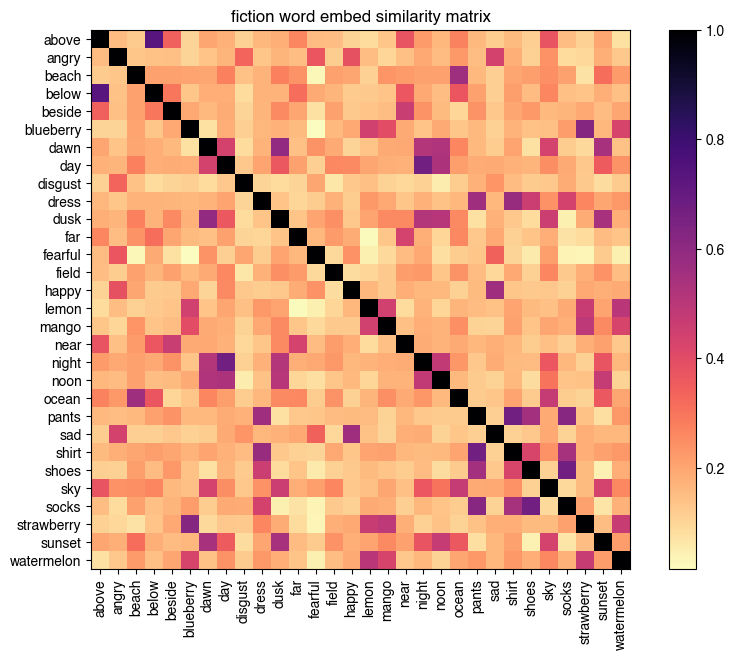

In [24]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(fic_reps), cmap='magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('fiction word embed similarity matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/fic_sim_mat.pdf', bbox_inches='tight')

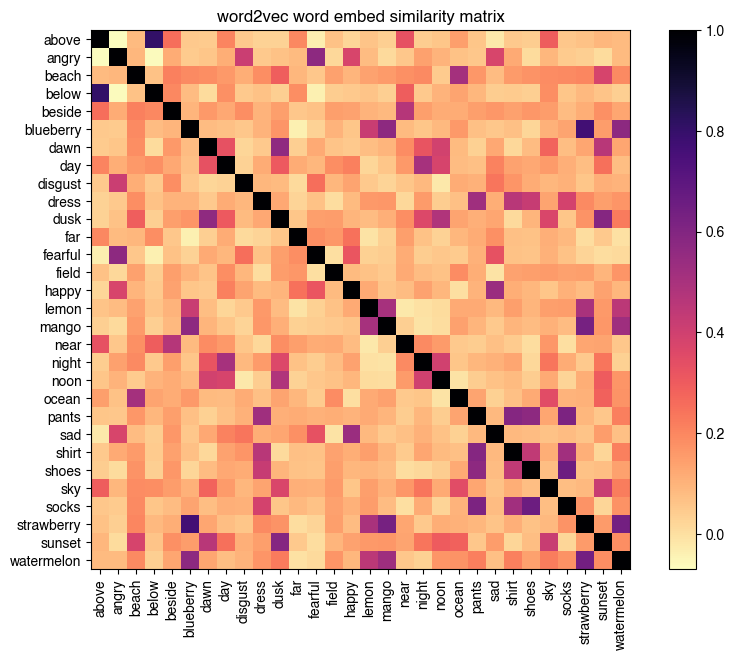

In [25]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(w2v_reps), cmap= 'magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('word2vec word embed similarity matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/w2v_sim_mat.pdf', bbox_inches='tight')

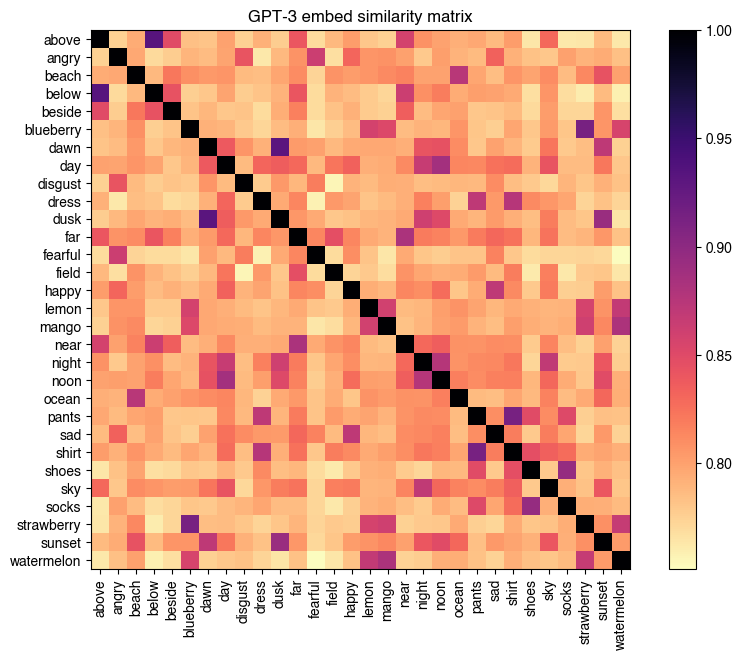

In [26]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(gpt_reps), cmap= 'magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('GPT-3 embed similarity matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/gpt_sim_mat.pdf', bbox_inches='tight')

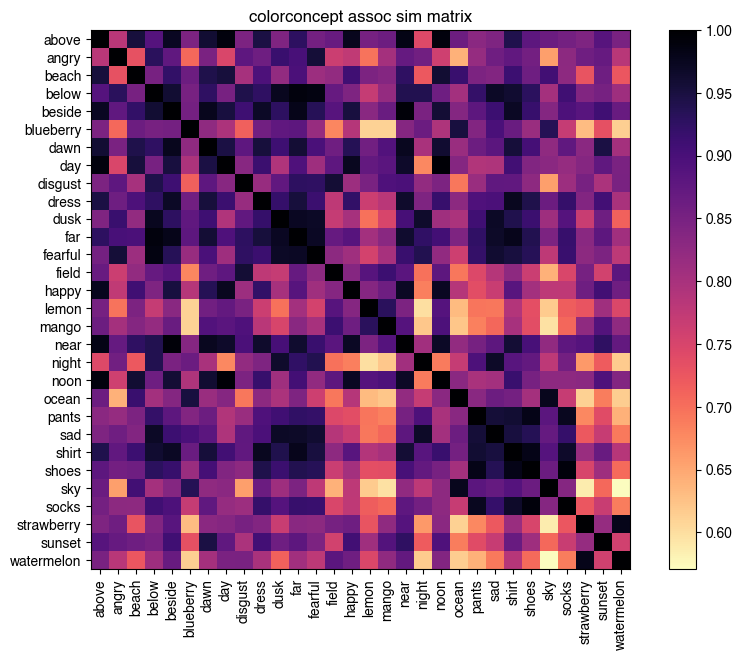

In [27]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(ratings.iloc[:,1:]), cmap='magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('colorconcept assoc sim matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/ratings_sim_mat.pdf', bbox_inches='tight')

In [28]:

w2v_df = pd.concat([pd.DataFrame(concept_list.reshape(30,1), columns = ['concepts']),pd.DataFrame(w2v_reps)], axis=1)
fic_df = pd.concat([pd.DataFrame(concept_list.reshape(30,1), columns = ['concepts']),pd.DataFrame(fic_reps)], axis=1)
gpt_df = pd.concat([pd.DataFrame(concept_list.reshape(30,1), columns = ['concepts']),pd.DataFrame(gpt_reps)], axis=1)


In [29]:
ratings_c = ratings.iloc[:,1:] - ratings_cmeans
u, s, vt = np.linalg.svd(ratings_c,full_matrices=False)

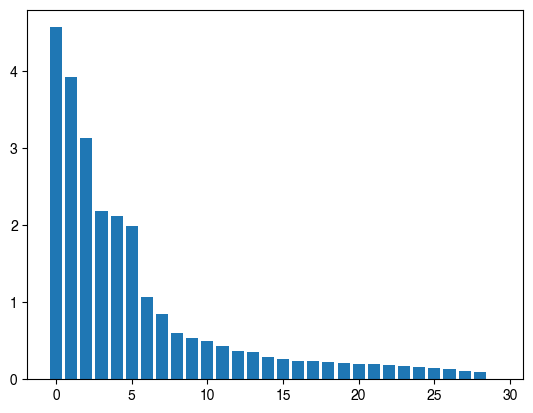

In [30]:
plt.bar(np.arange(len(s)),s)
s = np.diag(s)

In [31]:
# z_ = (u@s).shape
ratings_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u[:,0],'c2':u[:,1],'c3':u[:,2]}), ratings_c],axis=1)


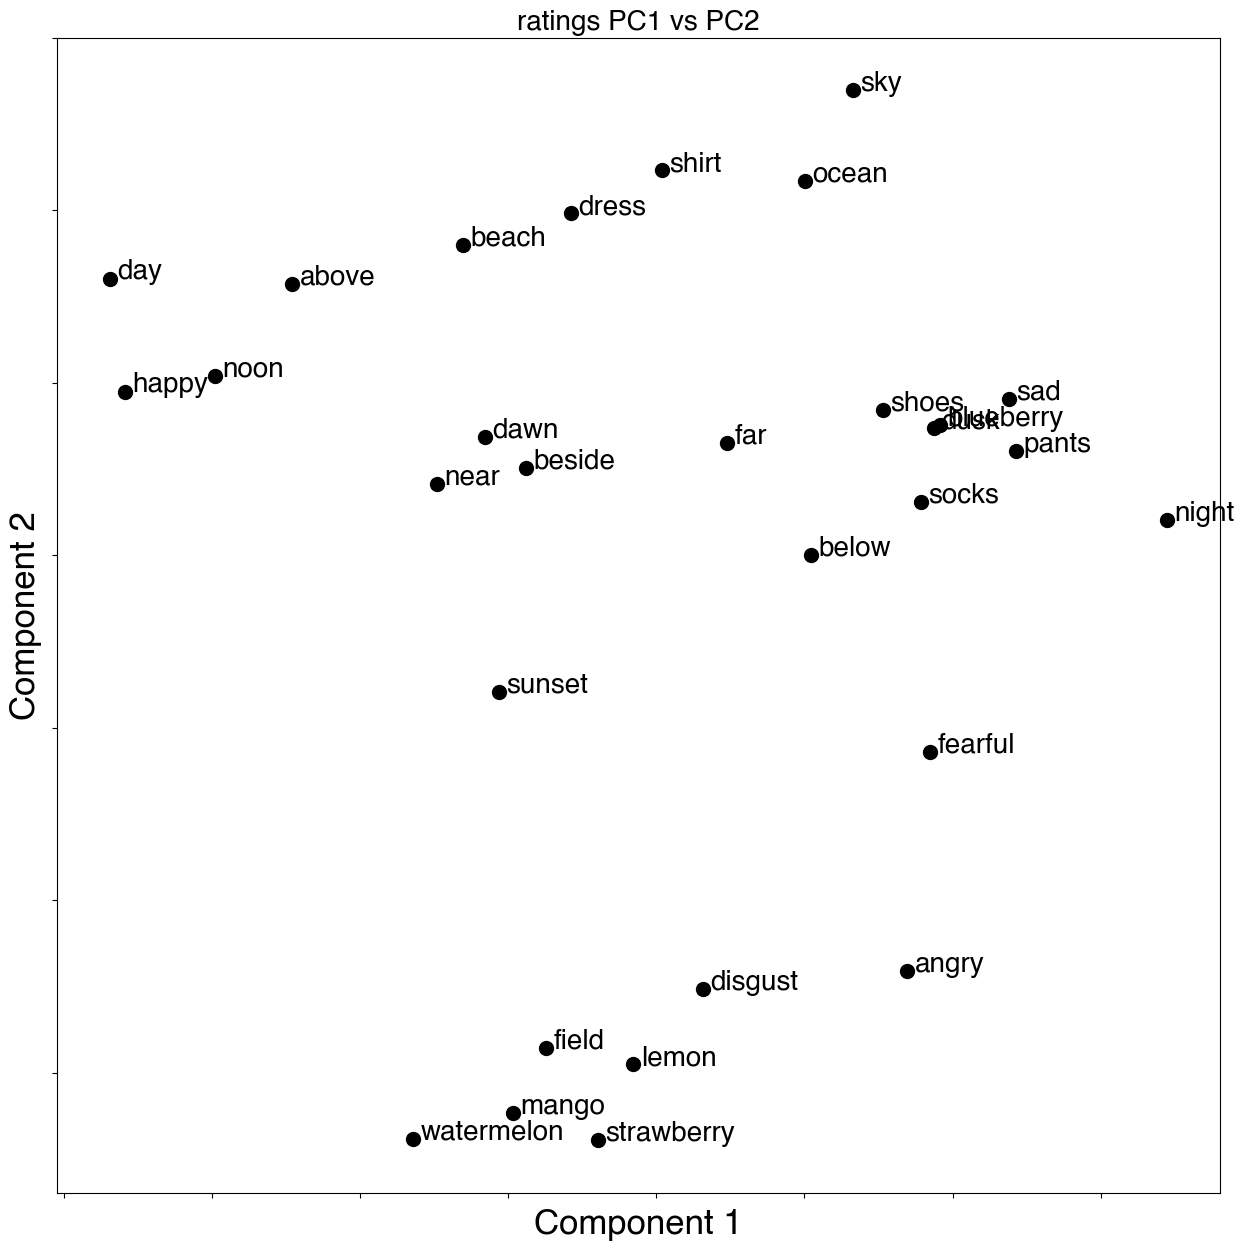

In [32]:
fig= plt.figure(figsize=(15,15))
# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(ratings_pc_df.c1,ratings_pc_df.c2, s=100, c='k')
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (ratings_pc_df.c1[i]+0.005,ratings_pc_df.c2[i]),fontsize=20)
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_title('ratings PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/ratings_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



In [33]:
w2v_reps_c = w2v_df.iloc[:,1:].apply(lambda x: x- x.mean())
w2v_reps_c_means = w2v_df.iloc[:,1:].mean(axis = 0).values
w2v_reps_c = w2v_reps_c.add_suffix('_w')

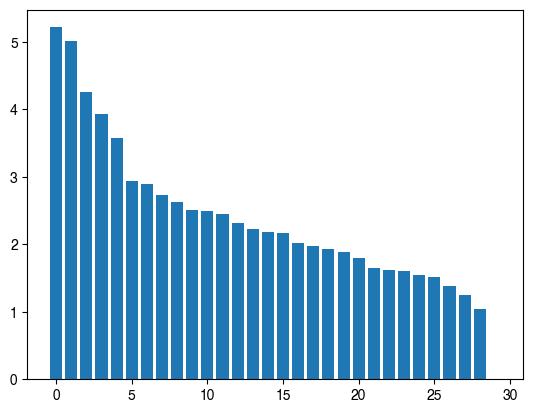

In [34]:
##plot the eigenvalues in a way that makes it clear that there's at least some low rank and a principled way to select the top few principal components
u_2, s_2, vt_2 = np.linalg.svd(w2v_reps_c,full_matrices=False)
plt.bar(np.arange(len(s_2)),s_2)
s_2 = np.diag(s_2)

In [35]:
w2v_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u_2[:,0],'c2':u_2[:,1],'c3':u_2[:,2]}), w2v_reps_c],axis=1)

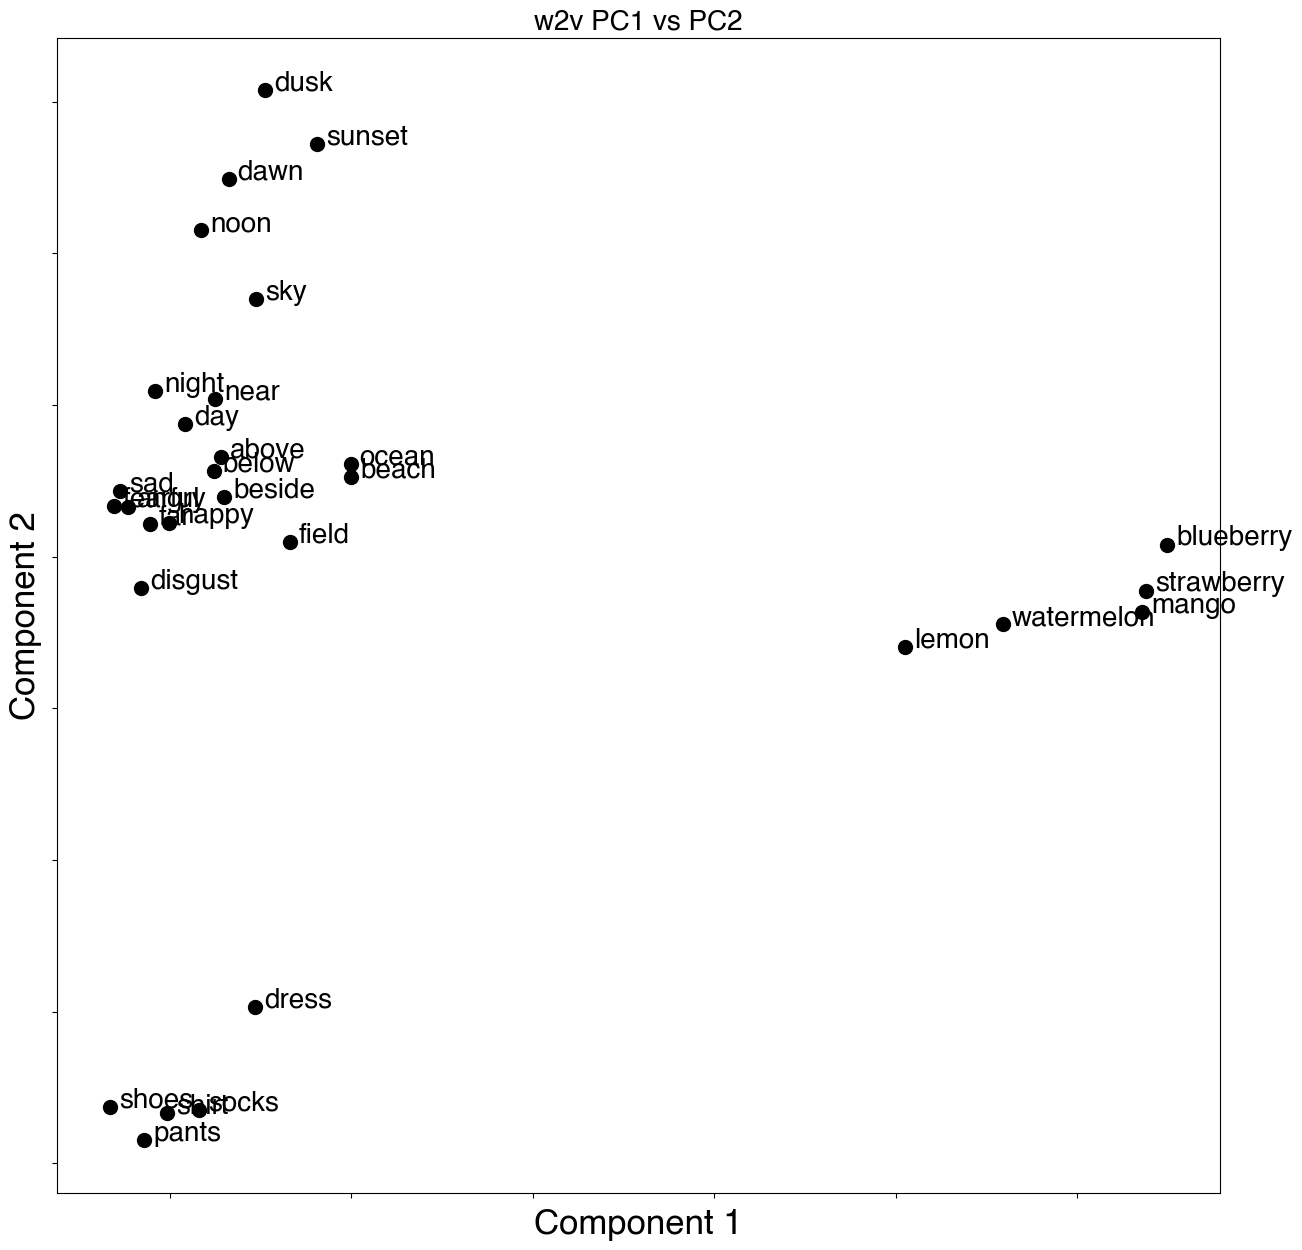

In [36]:
fig= plt.figure(figsize=(15,15))
# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(w2v_pc_df['c1'], w2v_pc_df['c2'], s=100, c='k')
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (w2v_pc_df.c1[i]+0.005,w2v_pc_df.c2[i]),fontsize=20)
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_title('w2v PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/w2v_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



Text(0.5, 0.92, 'word2vec space')

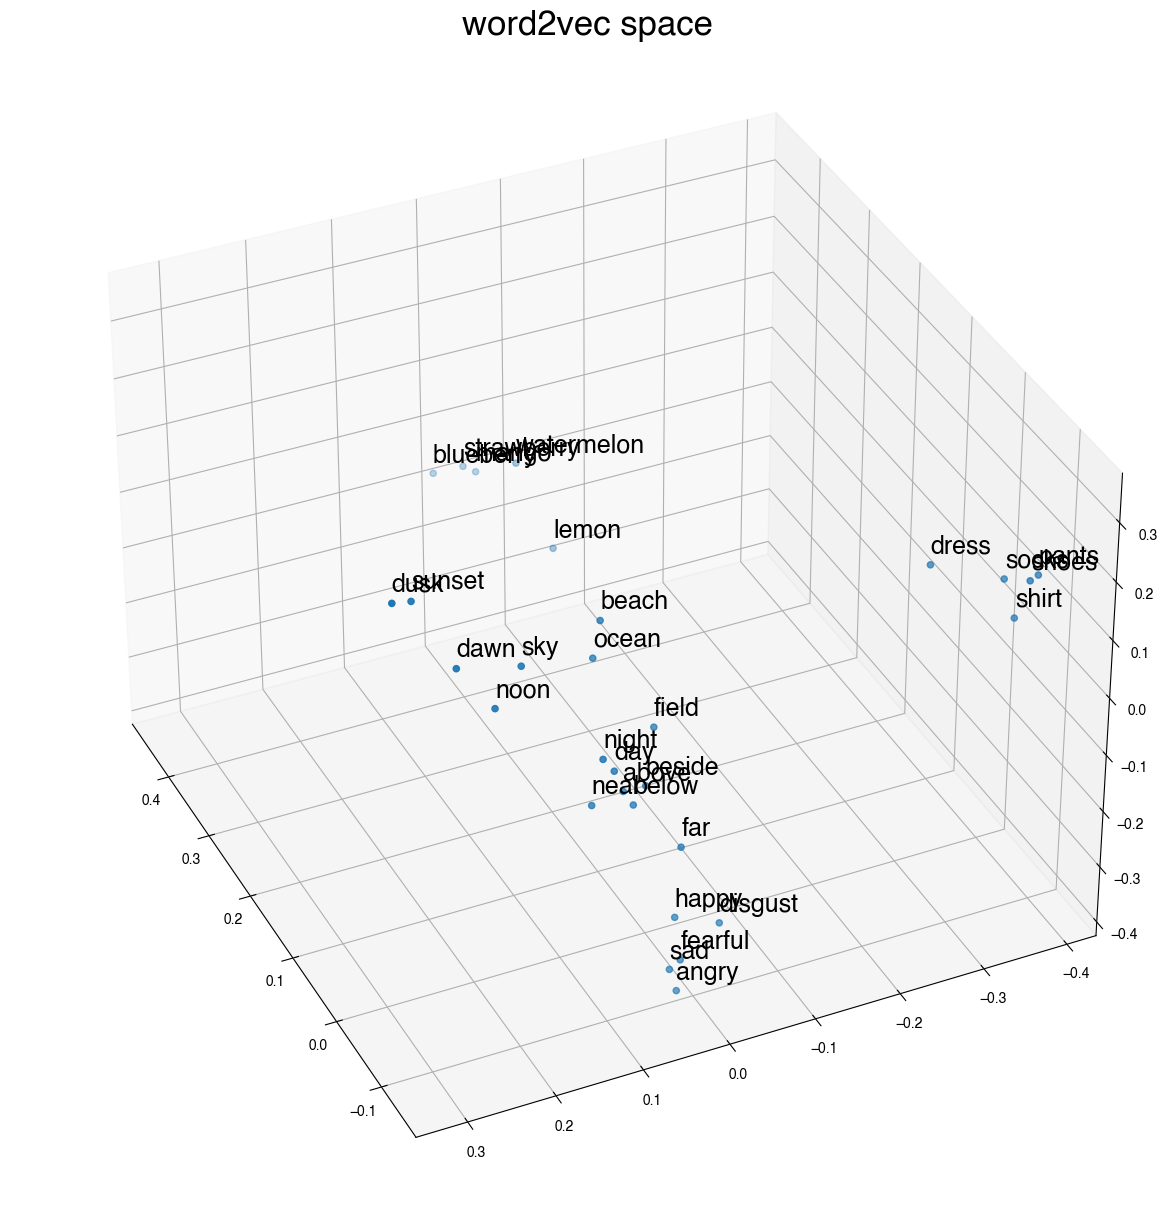

In [37]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( w2v_pc_df['c1'], w2v_pc_df['c2'], w2v_pc_df['c3'])
for i, txt in enumerate(w2v_pc_df['concepts']):
    ax.text(w2v_pc_df['c1'].iloc[i],w2v_pc_df['c2'].iloc[i], w2v_pc_df['c3'].iloc[i]+.02, txt, fontsize=18)
plt.title('word2vec space', fontsize=25)

In [38]:
fic_reps_c = fic_df.iloc[:,1:].apply(lambda x: x- x.mean())
fic_reps_c_means = fic_df.iloc[:,1:].mean(axis = 0).values
fic_reps_c = fic_reps_c.add_suffix('_f')


<BarContainer object of 30 artists>

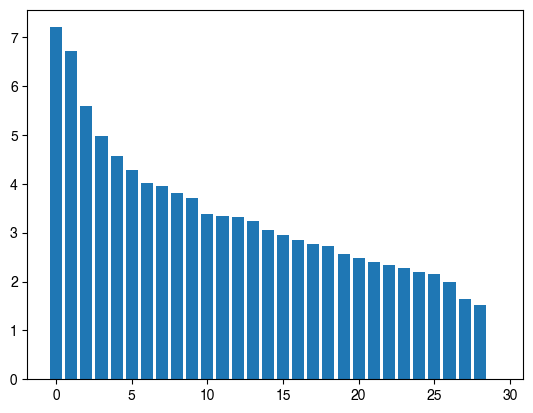

In [39]:
u_3, s_3, vt_3 = np.linalg.svd(fic_reps_c,full_matrices=False)
plt.bar(np.arange(len(s_3)),s_3)

In [40]:
fic_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u_3[:,0],'c2':u_3[:,1],'c3':u_3[:,2]}), fic_reps_c],axis=1)

Text(0.5, 0.92, 'fiction embedding space')

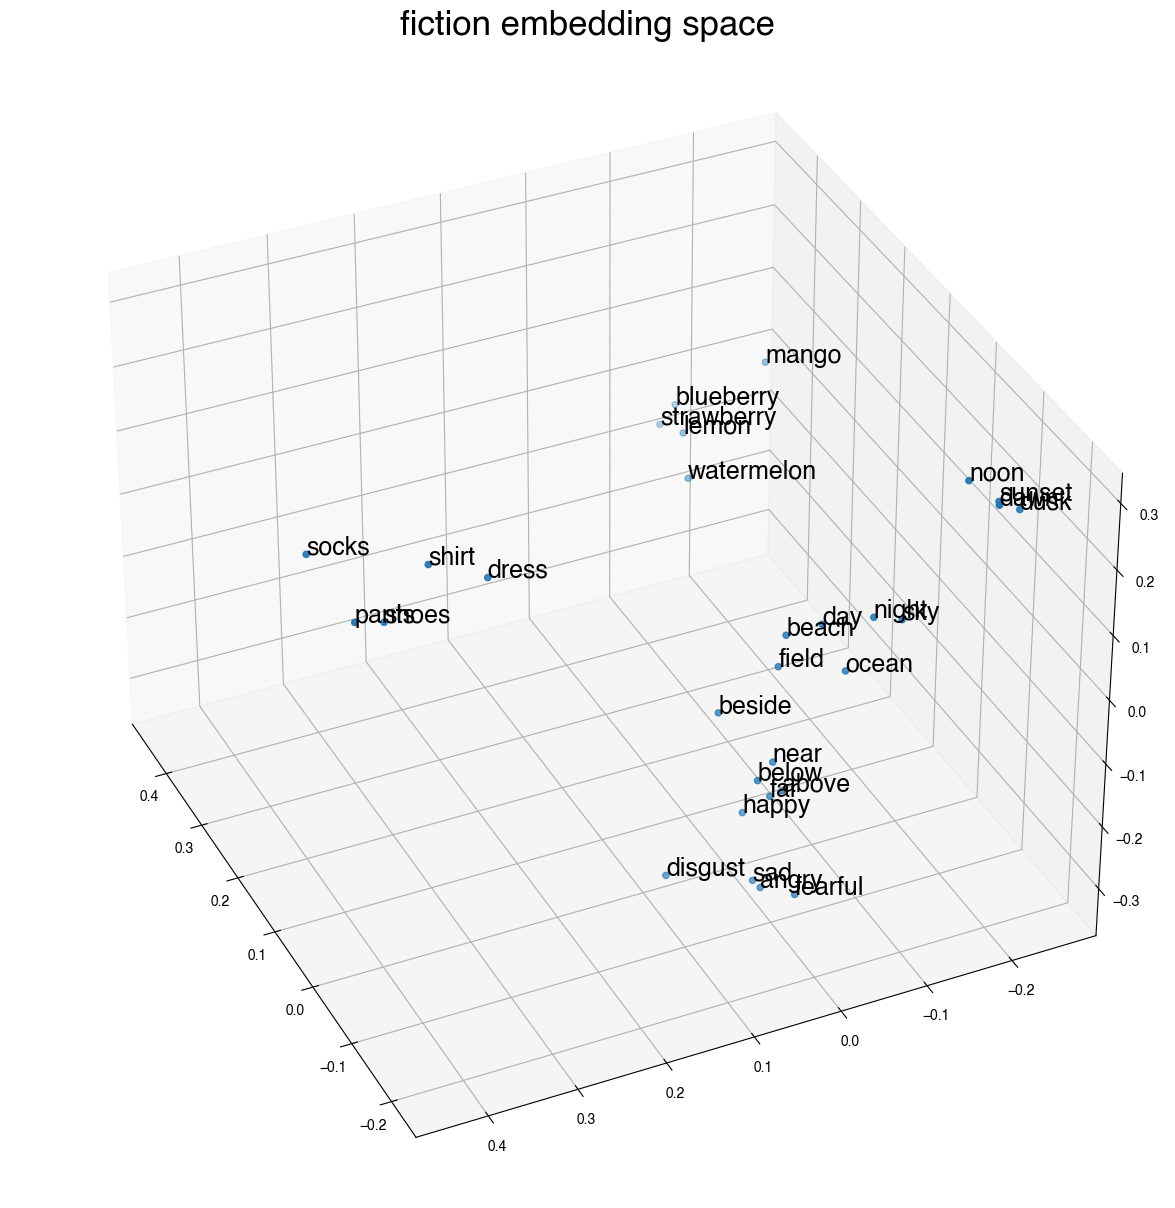

In [41]:
fig= plt.figure(figsize=(15,15))
ax = plt.axes(projection='3d')
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( fic_pc_df['c1'], fic_pc_df['c2'], fic_pc_df['c3'])
for i, txt in enumerate(fic_pc_df['concepts']):
    ax.text(fic_pc_df['c1'].iloc[i],fic_pc_df['c2'].iloc[i], fic_pc_df['c3'].iloc[i], txt, fontsize=18)
plt.title('fiction embedding space', fontsize=25)

In [42]:
gpt_reps_c = gpt_df.iloc[:,1:].apply(lambda x: x- x.mean())
gpt_reps_c_means = gpt_df.iloc[:,1:].mean(axis = 0).values
gpt_reps_c = gpt_reps_c.add_suffix('_g')


<BarContainer object of 30 artists>

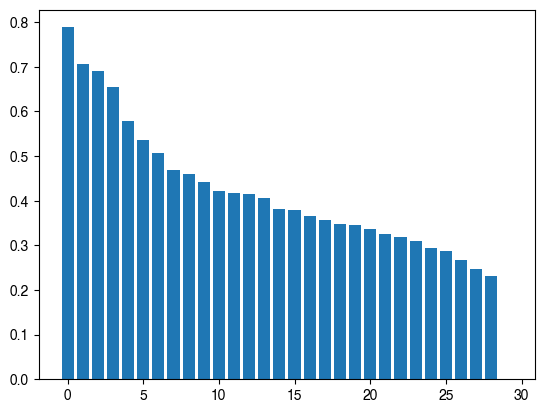

In [43]:
u_4, s_4, vt_4 = np.linalg.svd(gpt_reps_c,full_matrices=False)
plt.bar(np.arange(len(s_4)),s_4)

In [44]:
gpt_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u_4[:,0],'c2':u_4[:,1],'c3':u_4[:,2]}), gpt_reps_c],axis=1)

In [45]:
# ratings = ratings.sort_values(by=['concepts']).reset_index(drop=True)
# ratings_c = ratings.iloc[:,1:] - ratings_cmeans
# u, s, vt = np.linalg.svd(ratings_c,full_matrices=False)

z_ = (u@s)
ratings_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':z_[:,0],'c2':z_[:,1],'c3':z_[:,2],'c4':z_[:,3],'c5':z_[:,4],'c6':z_[:,5]}), ratings_c],axis=1)

reg_df = pd.concat([pd.Series(concept_list,name='concepts'),ratings_c,w2v_reps_c, fic_reps_c, gpt_reps_c, ratings_pc_df[['c1','c2','c3','c4','c5','c6']]],axis=1)

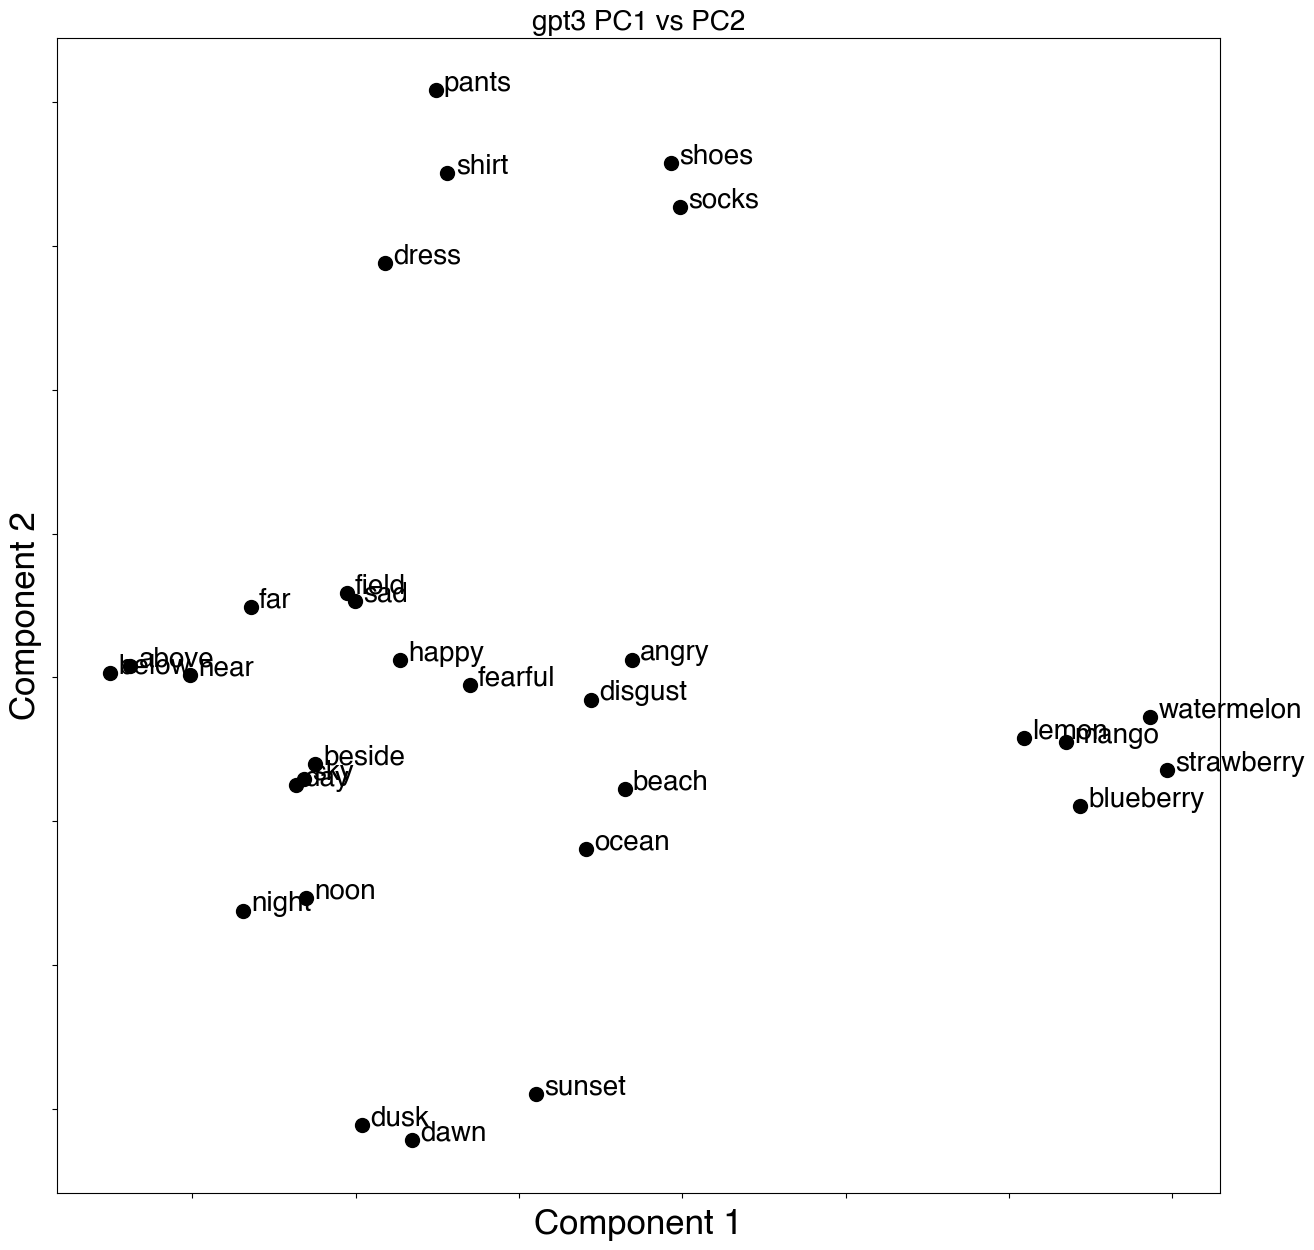

In [46]:
fig= plt.figure(figsize=(15,15))
# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(gpt_pc_df['c1'], gpt_pc_df['c2'], s=100, c='k')
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (gpt_pc_df.c1[i]+0.005,gpt_pc_df.c2[i]),fontsize=20)
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_title('gpt3 PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/gpt_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



In [47]:
reg_df= reg_df.sort_values(by=['concepts'])
reg_df.to_csv('../../data/reg_df.csv',index=False)


In [48]:
pred_coords_w2v = pd.read_csv('../../data/w2v_predicted_coords.csv')
pred_coords_w2v = pred_coords_w2v.sort_values(by='concepts',key= lambda x: x.map(concept_order)).reset_index(drop=True)
pred_coords_fic = pd.read_csv('../../data/fic_predicted_coords.csv')
pred_coords_fic = pred_coords_fic.sort_values(by='concepts',key= lambda x: x.map(concept_order)).reset_index(drop=True)
pred_coords_gpt = pd.read_csv('../../data/gpt_predicted_coords.csv')
pred_coords_gpt = pred_coords_gpt.sort_values(by='concepts',key= lambda x: x.map(concept_order)).reset_index(drop=True)

In [49]:
# fig= plt.figure(figsize=(15,15))

# ax = plt.axes(projection='3d')
# #ax.view_init(30, 210)
# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( pred_coords_w2v['c1_pred'], pred_coords_w2v['c2_pred'], pred_coords_w2v['c3_pred'])
# for i, txt in enumerate(pred_coords_w2v['concepts']):
#     ax.text(pred_coords_w2v['c1_pred'].iloc[i],pred_coords_w2v['c2_pred'].iloc[i], pred_coords_w2v['c3_pred'].iloc[i], txt, fontsize=18)
# plt.title('Predicted coordinates w2v', fontsize=25)



Text(0.5, 0.92, 'Predicted coordinates fiction')

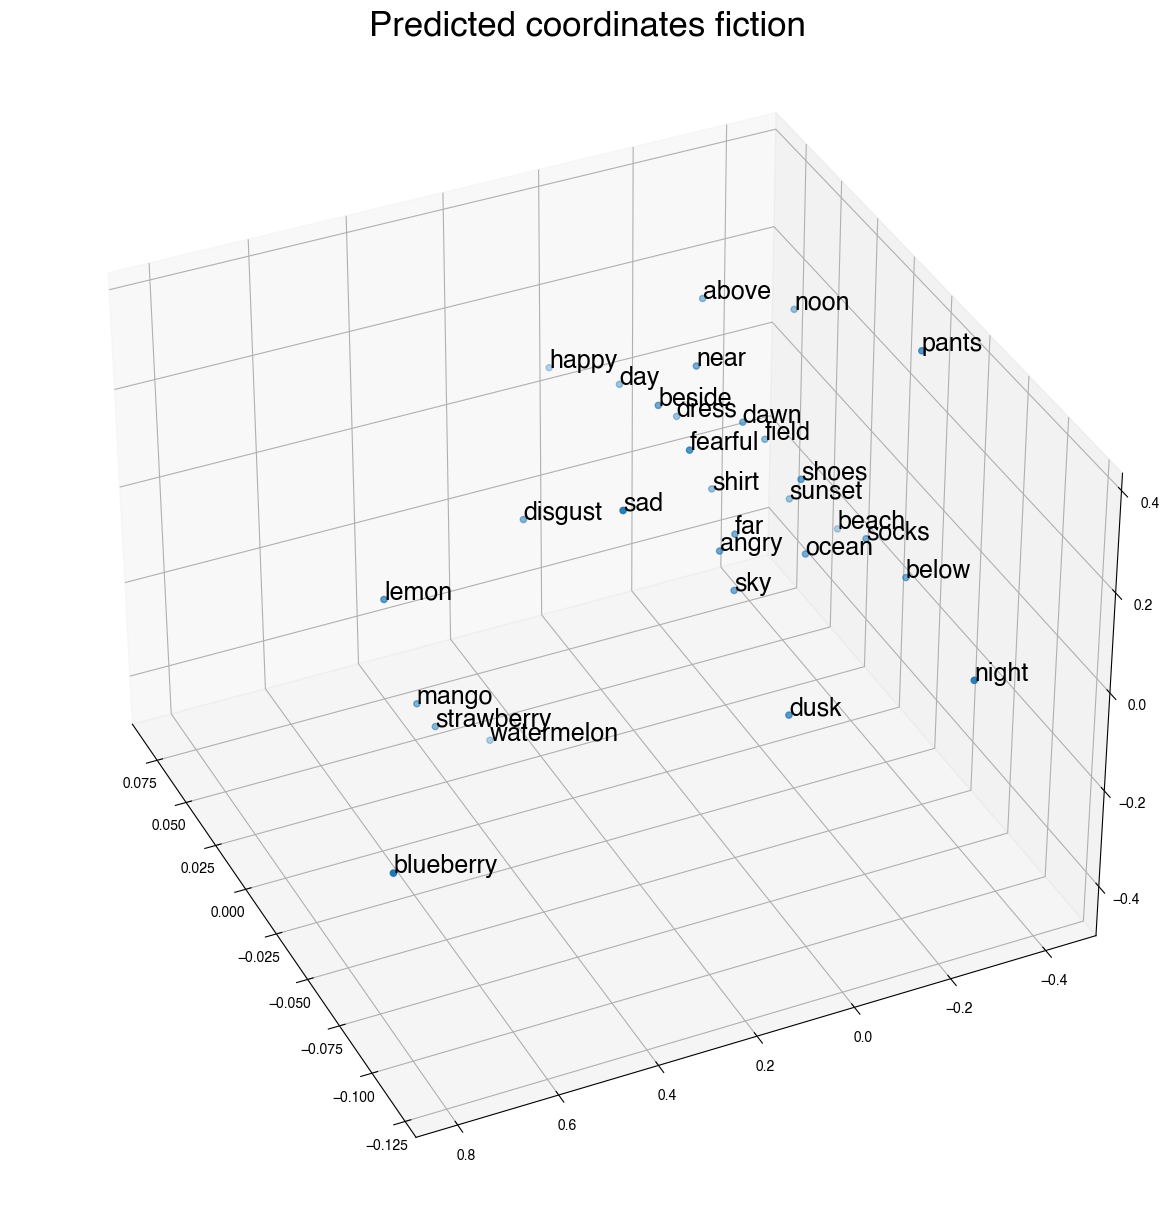

In [50]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
#ax.view_init(30, 210)
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( pred_coords_fic['c1_pred'], pred_coords_fic['c2_pred'], pred_coords_fic['c3_pred'])
for i, txt in enumerate(pred_coords_fic['concepts']):
    ax.text(pred_coords_fic['c1_pred'].iloc[i],pred_coords_fic['c2_pred'].iloc[i], pred_coords_fic['c3_pred'].iloc[i], txt, fontsize=18)
plt.title('Predicted coordinates fiction', fontsize=25)


Text(0.5, 0.92, 'Predicted coordinates gpt')

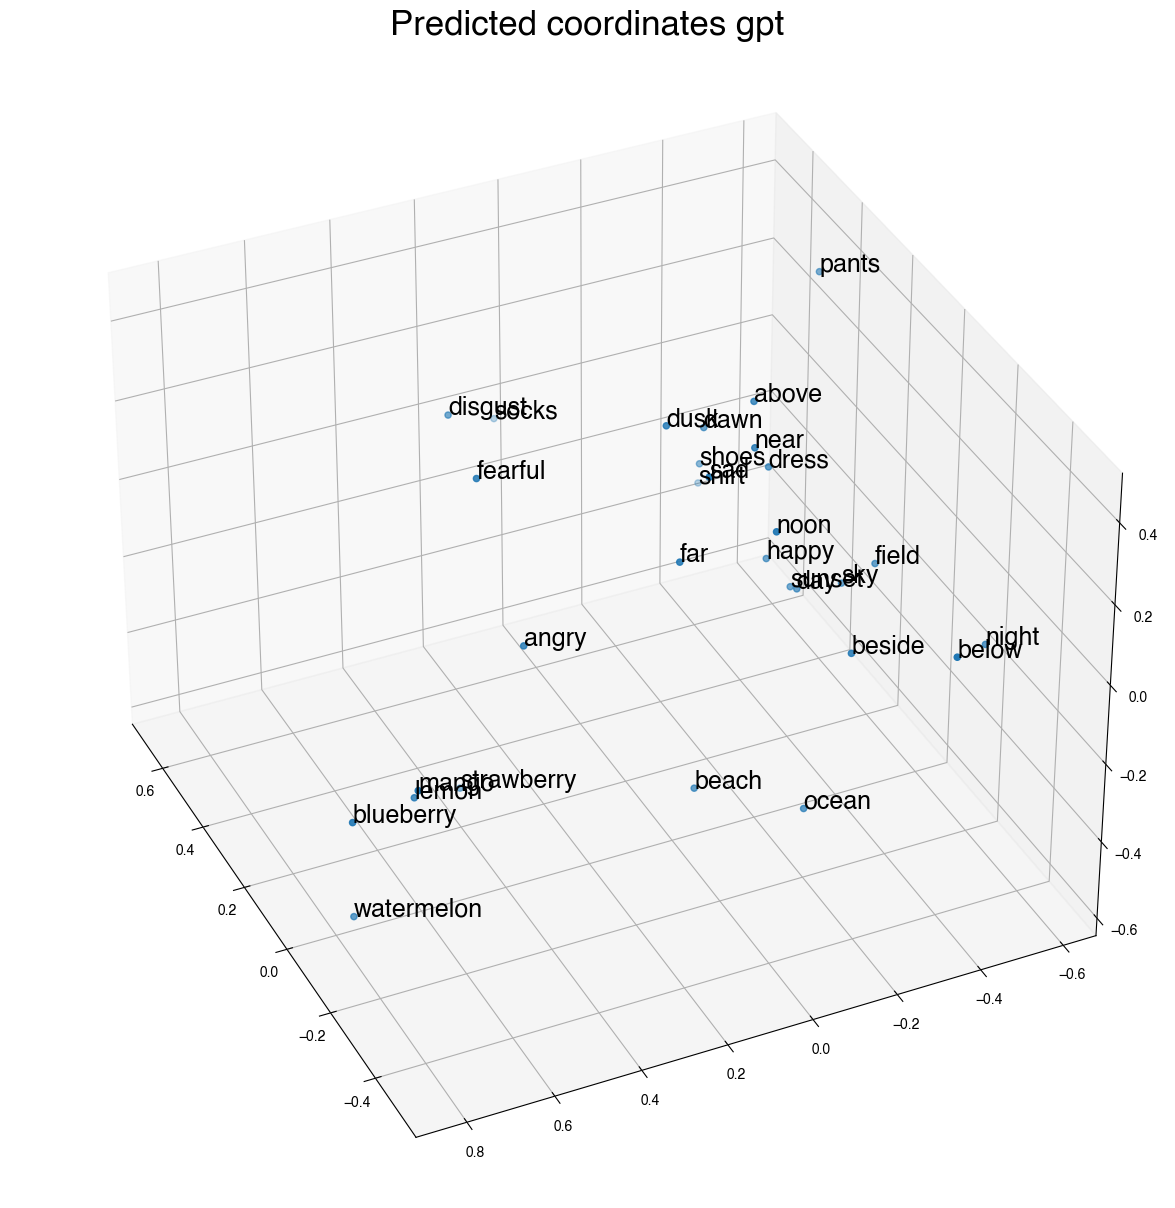

In [51]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
#ax.view_init(30, 210)
ax.view_init(35, 155)

ax.scatter3D( pred_coords_gpt['c1_pred'], pred_coords_gpt['c2_pred'], pred_coords_gpt['c3_pred'])
for i, txt in enumerate(pred_coords_gpt['concepts']):
    ax.text(pred_coords_gpt['c1_pred'].iloc[i],pred_coords_gpt['c2_pred'].iloc[i], pred_coords_gpt['c3_pred'].iloc[i], txt, fontsize=18)
plt.title('Predicted coordinates gpt', fontsize=25)



In [52]:
ratings = ratings.sort_values(by=['concepts'])

In [53]:
from tqdm import tqdm
from sklearn import linear_model as lm
cons = []
cors = []

for i,this_concept in tqdm(enumerate(ratings.concepts.values)):

    concept_ratings = ratings.iloc[:,1:] - ratings_cmeans
    concept_ratings_inv= ratings[ratings.concepts!=this_concept]
    concept_ratings_inv = concept_ratings_inv.iloc[:,1:] - ratings_cmeans
    #color_inds = return_rows(concept_ratings_inv,8)
    

    u,s,Vh =  np.linalg.svd(concept_ratings_inv, full_matrices=True)
    s = np.diag(s)
    factor_matrix = u@s
    basis_vecs = Vh[0:6,:]
   
    

    predicted_ratings = pred_coords_fic[pred_coords_fic.concepts==this_concept].iloc[:,2:].values@basis_vecs
    true_ratings = ratings[ratings.concepts==this_concept].iloc[:,1:] - ratings_cmeans
    if this_concept=='noon':
        print(basis_vecs)

    this_cor = np.corrcoef(predicted_ratings,true_ratings)[0,1] 
    cons.append(this_concept)
    cors.append(this_cor)
tmp_fic = pd.DataFrame({'concepts':cons,'cors':cors})

cons = []
cors = []
for i,this_concept in tqdm(enumerate(ratings.concepts.values)):

    concept_ratings = ratings.iloc[:,1:] - ratings_cmeans
    concept_ratings_inv= ratings[ratings.concepts!=this_concept]
    concept_ratings_inv = concept_ratings_inv.iloc[:,1:] - ratings_cmeans
    #color_inds = return_rows(concept_ratings_inv,8)
    

    u,s,Vh =  np.linalg.svd(concept_ratings_inv, full_matrices=True)
    s = np.diag(s)
    factor_matrix = u@s
    basis_vecs = Vh[0:6,:]

    predicted_ratings = pred_coords_gpt[pred_coords_gpt.concepts==this_concept].iloc[:,2:].values@basis_vecs
    true_ratings = ratings[ratings.concepts==this_concept].iloc[:,1:] - ratings_cmeans

    this_cor = np.corrcoef(predicted_ratings,true_ratings)[0,1] 
    cons.append(this_concept)
    cors.append(this_cor)
tmp_gpt = pd.DataFrame({'concepts':cons,'cors':cors})

30it [00:00, 527.85it/s]


[[ 1.35983680e-02  1.26356843e-01 -6.64075004e-03 -6.17747118e-02
   1.18008489e-02  1.67100315e-01  1.52211205e-02  5.79427736e-02
  -5.73412217e-02 -9.68481924e-02 -6.91990857e-02  1.90762374e-01
   9.59308161e-02 -1.80397565e-02  1.00062070e-01 -2.05755582e-04
  -1.19524274e-01  4.37620055e-02 -8.28270388e-02 -1.29624877e-01
  -1.07828956e-01  5.23723804e-02 -6.01707140e-02 -8.05446337e-02
   2.70760189e-01  2.47382632e-01  1.92522570e-01  8.32206956e-02
  -2.93291948e-02  1.10533331e-03  8.69499947e-02 -2.73739235e-02
  -1.42902911e-01 -1.15199056e-01 -1.43386164e-01 -1.27091628e-01
  -1.36819306e-01 -1.85400361e-02 -4.96950207e-02 -1.09806616e-01
  -1.24703615e-01  1.09725391e-01  6.90127587e-02 -3.36009996e-02
  -7.50787046e-02  1.00821893e-01 -1.90224327e-02 -1.28379128e-01
  -1.18395664e-01 -1.32409759e-01 -1.17668578e-01 -1.74937315e-01
  -1.75827021e-01 -5.40715201e-02 -1.32190635e-01 -1.57622385e-01
   1.74421987e-02 -1.17114700e-01 -1.45260009e-01 -2.50046883e-02
  -1.48774

30it [00:00, 934.87it/s]


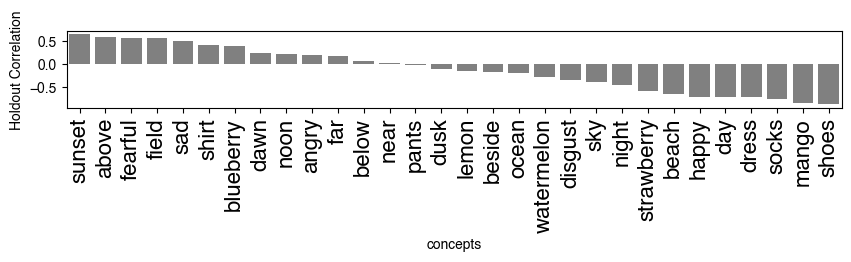

In [54]:
### make a barplot of tmp with concepts as x axis and cors as y axis and sort by cors
import seaborn as sns

tmp_fic = tmp_fic.sort_values(by='cors',ascending=False).reset_index(drop=True)
plt.figure(figsize=(10,1))
sns.barplot(x='concepts',y='cors',data=tmp_fic, color='gray')
plt.ylabel('Holdout Correlation',fontsize=10)
plt.xticks(np.arange(tmp_fic.shape[0]),tmp_fic.concepts,rotation=90,fontsize=16)
plt.show()


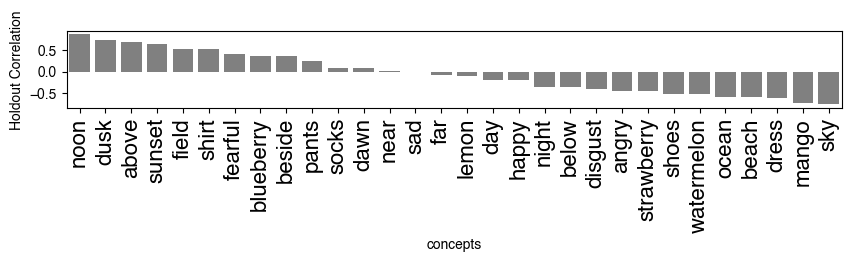

In [55]:

tmp_gpt = tmp_gpt.sort_values(by='cors',ascending=False).reset_index(drop=True)
plt.figure(figsize=(10,1))
sns.barplot(x='concepts',y='cors',data=tmp_gpt, color='gray')
plt.ylabel('Holdout Correlation',fontsize=10)
plt.xticks(np.arange(tmp_gpt.shape[0]),tmp_gpt.concepts,rotation=90,fontsize=16)
plt.show()

In [56]:
### do a spearman rank correlation between tmp_gpt and tmp_fic for the concepts column
from scipy.stats import spearmanr
spearmanr(tmp_gpt.concepts,tmp_fic.concepts)

SignificanceResult(statistic=0.21512791991101224, pvalue=0.2535929211765342)

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

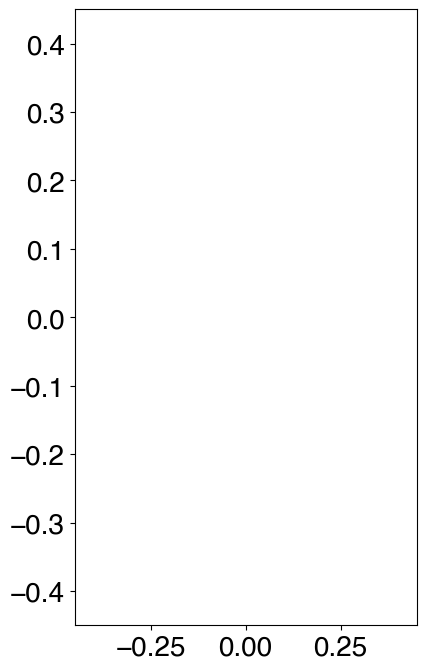

In [57]:
# plt.figure(figsize=(8,8))
plt.figure(figsize=(5*3, 8))
plt.rcParams.update({'font.size': 20})
ax = plt.subplot(1, 3, 1)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c1'],pred_coords_w2v['c1_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c1'],pred_coords_w2v['c1_pred'],1)
ax.plot(ratings_pc_df['c1'], m*ratings_pc_df['c1'] + b, color='teal', linewidth=3)
ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 1', fontsize=25) 

ax = plt.subplot(1, 3, 2)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c2'],pred_coords_w2v['c2_pred'],'o',markersize=10)
### compute and draw the line of best fit between the two sets of coordinates
m, b = np.polyfit(ratings_pc_df['c2'],pred_coords_w2v['c2_pred'], 1)
ax.plot(ratings_pc_df['c2'], m*ratings_pc_df['c2'] + b, color='teal', linewidth=3)
ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 2', fontsize=25) 

ax = plt.subplot(1, 3, 3)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c3'],pred_coords_w2v['c3_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c3'],pred_coords_w2v['c3_pred'], 1)
ax.plot(ratings_pc_df['c3'], m*ratings_pc_df['c3'] + b, color='teal', linewidth=3)
ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 3', fontsize=25) 

plt.tight_layout()
plt.suptitle('Word2Vec', fontsize=25)
plt.subplots_adjust(top=0.85)
plt.savefig('../../data/recon_assocs/w2v_predicted_vs_true.pdf',dpi=300, bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


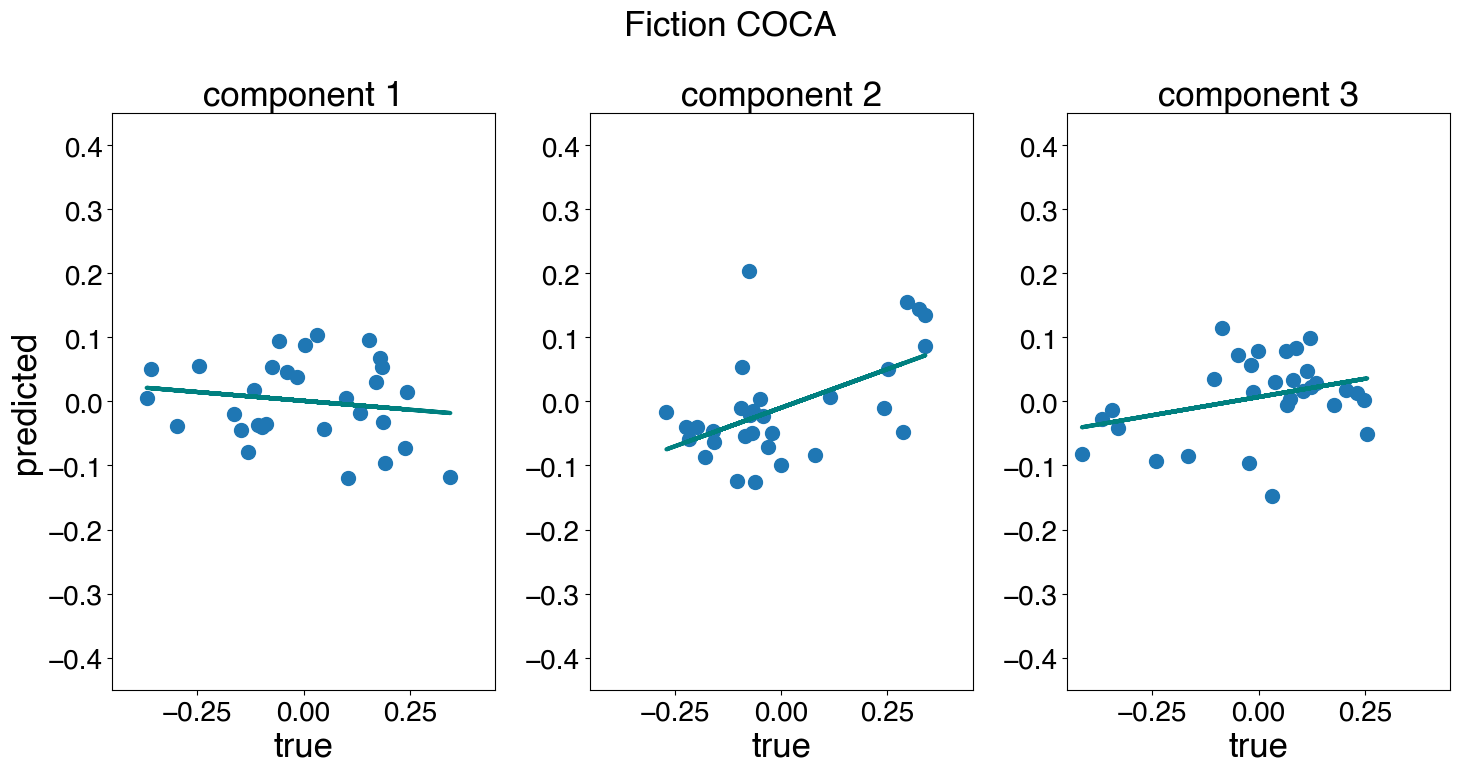

In [ ]:
# plt.figure(figsize=(8,8))
plt.figure(figsize=(5*3, 8))
ax = plt.subplot(1, 3, 1)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c1'],pred_coords_fic['c1_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c1'],pred_coords_fic['c1_pred'],1)
ax.plot(ratings_pc_df['c1'], m*ratings_pc_df['c1'] + b, color='teal', linewidth=3)
ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 1', fontsize=25) 

ax = plt.subplot(1, 3, 2)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c2'],pred_coords_fic['c2_pred'],'o',markersize=10)
### compute and draw the line of best fit between the two sets of coordinates
m, b = np.polyfit(ratings_pc_df['c2'],pred_coords_fic['c2_pred'], 1)
ax.plot(ratings_pc_df['c2'], m*ratings_pc_df['c2'] + b, color='teal', linewidth=3)
# ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 2', fontsize=25)

ax = plt.subplot(1, 3, 3)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c3'],pred_coords_fic['c3_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c3'],pred_coords_fic['c3_pred'], 1)
ax.plot(ratings_pc_df['c3'], m*ratings_pc_df['c3'] + b, color='teal', linewidth=3)
# ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 3', fontsize=25)
plt.tight_layout()
plt.suptitle('Fiction COCA', fontsize=25)
## add some space between the suptitle and the subplots
plt.subplots_adjust(top=0.85)
plt.savefig('../../data/recon_assocs/fic_predicted_vs_true.pdf',dpi=300, bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


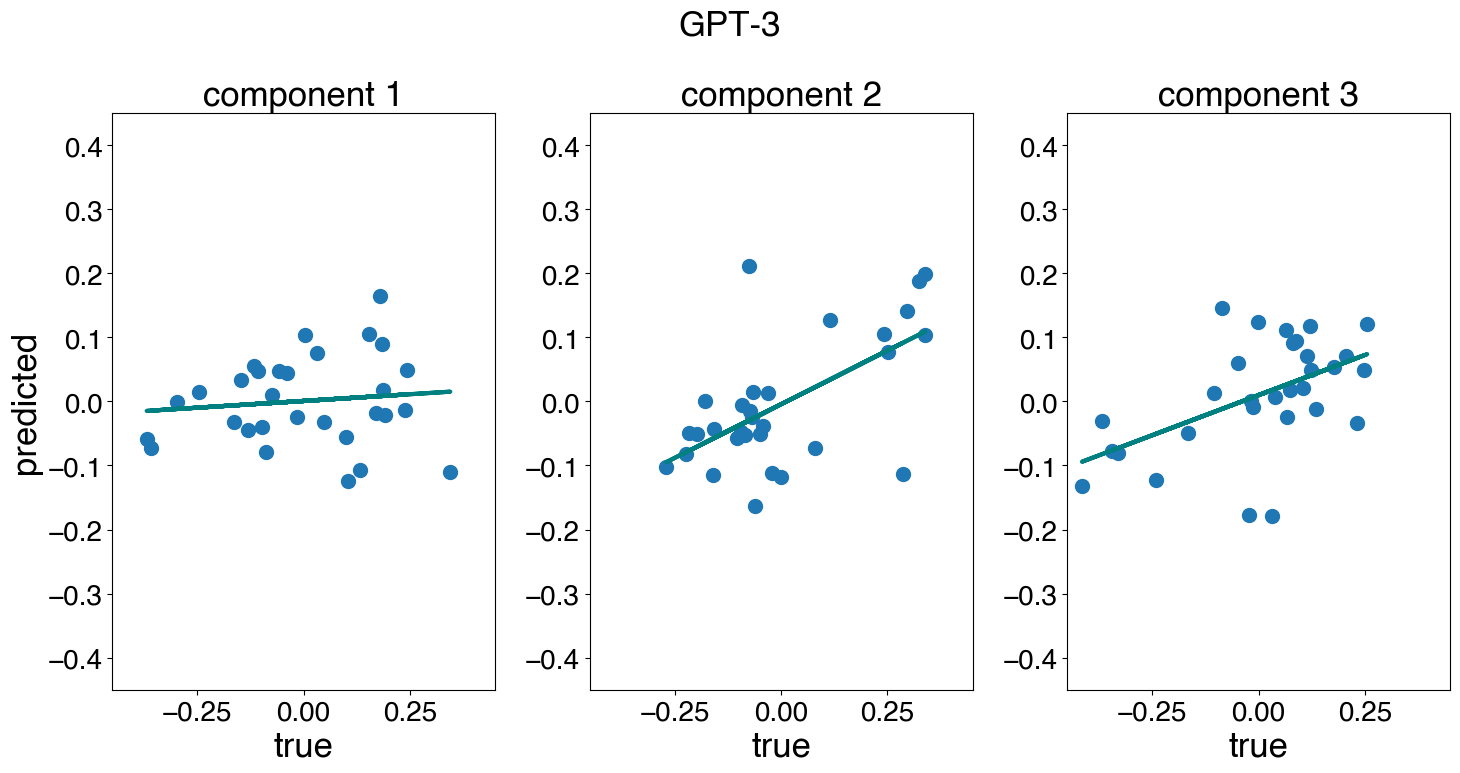

In [ ]:
# plt.figure(figsize=(8,8))
plt.figure(figsize=(5*3, 8))
ax = plt.subplot(1, 3, 1)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c1'],pred_coords_gpt['c1_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c1'],pred_coords_gpt['c1_pred'],1)
ax.plot(ratings_pc_df['c1'], m*ratings_pc_df['c1'] + b, color='teal', linewidth=3)
ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 1', fontsize=25)

ax = plt.subplot(1, 3, 2)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c2'],pred_coords_gpt['c2_pred'],'o',markersize=10)
### compute and draw the line of best fit between the two sets of coordinates
m, b = np.polyfit(ratings_pc_df['c2'],pred_coords_gpt['c2_pred'], 1)
ax.plot(ratings_pc_df['c2'], m*ratings_pc_df['c2'] + b, color='teal', linewidth=3)
# ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 2', fontsize=25)

ax = plt.subplot(1, 3, 3)
ax.set_xlim(-.45,.45)
ax.set_ylim(-.45,.45)
ax.plot(ratings_pc_df['c3'],pred_coords_gpt['c3_pred'],'o',markersize=10)
m, b = np.polyfit(ratings_pc_df['c3'],pred_coords_gpt['c3_pred'], 1)
ax.plot(ratings_pc_df['c3'], m*ratings_pc_df['c3'] + b, color='teal', linewidth=3)
# ax.set_ylabel('predicted', fontsize=25)
ax.set_xlabel('true', fontsize=25)
ax.set_title('component 3', fontsize=25)

plt.tight_layout()
plt.suptitle('GPT-3', fontsize=25)
plt.subplots_adjust(top=0.85)
plt.savefig('../../data/recon_assocs/gpt_predicted_vs_true.pdf',dpi=300, bbox_inches='tight')



In [59]:

# cca_df =pd.read_csv("../data/cc_assoc.csv") #color-concept association matrix
# fic_df =pd.read_csv("../data/fic.csv") 	 #fiction word2vec
# w2v_df =pd.read_csv("../data/w2v.csv")      #standard word2vec
col3d_df  =pd.read_csv("../../data/semantic_alignment_data/color_salmon.csv") #salmon 3d embedding for color triplets
kind3d_df =pd.read_csv("../../data/semantic_alignment_data/kind_salmon.csv") #salmon 3d embedding for kind triplets
sym3d_df  =pd.read_csv("../../data/semantic_alignment_data/symbolic_salmon.csv") #salmon 3d embedding for symbol triplets
# cdict= read.csv("../data/color_dict_uw58.csv")

In [60]:
col3d_df

,concept,d1,d2,d3
0,dress,0.343331,-0.061265,0.157220
1,pants,0.052214,-0.291536,-0.043533
2,shirt,0.257647,-0.176287,-0.102500
3,shoes,0.131669,-0.299141,-0.203368
4,socks,0.133730,-0.244108,-0.275072
5,above,-0.034047,-0.068581,0.213683
6,below,-0.268034,-0.122212,-0.141975
7,beside,-0.176319,-0.166018,0.251397
8,far,-0.139099,0.218425,-0.020342
9,near,-0.127143,-0.176430,0.190812


In [61]:
plt.rcParams.update({'font.size': 10})

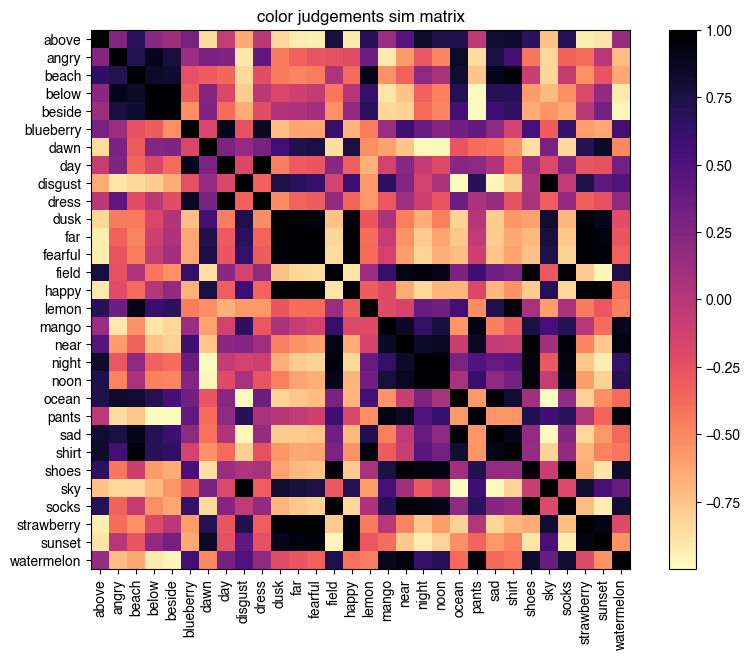

In [62]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(col3d_df[['d1','d2','d3']]), cmap='magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('color judgements sim matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/color_judge_sim_matrix.pdf',bbox_inches='tight')

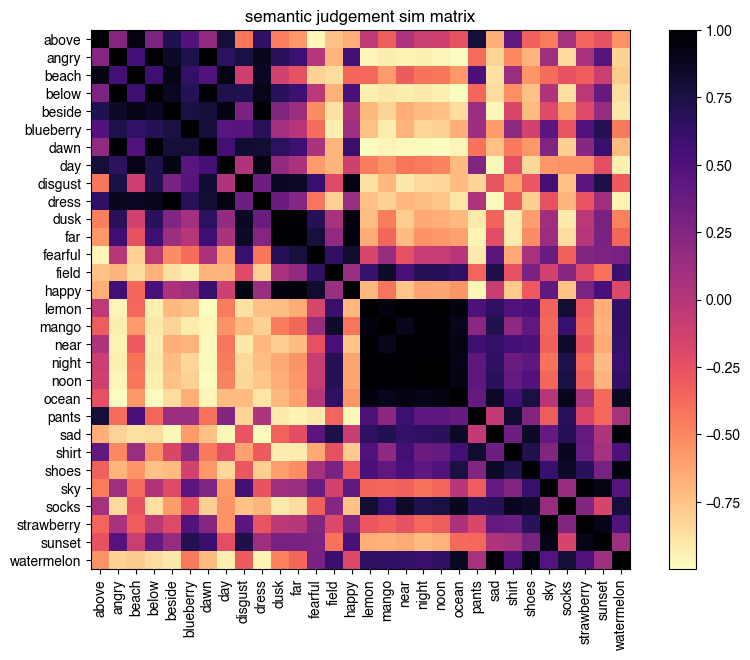

In [63]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(kind3d_df[['d1','d2','d3']]), cmap='magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('semantic judgement sim matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/semantic_judge_sim_matrix.pdf',bbox_inches='tight')

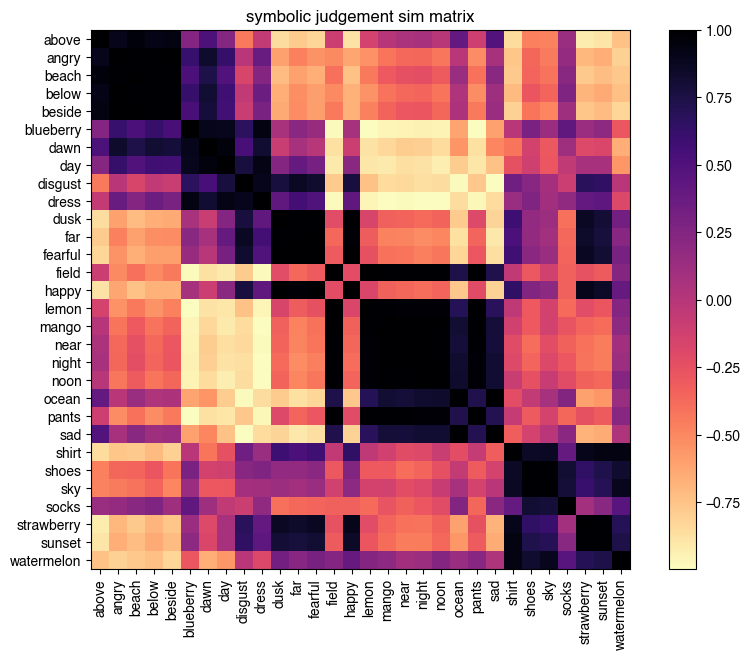

In [64]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(sym3d_df[['d1','d2','d3']]), cmap='magma_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('symbolic judgement sim matrix')
plt.colorbar()
plt.savefig('../../data/recon_assocs/symbolic_judge_sim_matrix.pdf',bbox_inches='tight')

In [65]:
import colorsys

def hex_to_rgb(hex_str):
    
    """Returns a tuple representing the given hex string as RGB.
    
    >>> hex_to_rgb('CC0000')
    (204, 0, 0)
    """
    if hex_str.startswith('#'):
        hex_str = hex_str[1:]
    return tuple([int(hex_str[i:i + 2], 16) for i in range(0, len(hex_str), 2)])

uw71coords['hue_angle'] = uw71coords.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.color_hex)))[0], axis=1)
uw71coords['saturation'] = uw71coords.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.color_hex)))[1], axis=1)
uw71coords['lightness'] = uw71coords.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.color_hex)))[2], axis=1)

In [66]:

uw71coords = uw71coords.sort_values(by=['hue_angle','saturation'],ascending=[True,False]).reset_index(drop=True)
sorted_col_order = uw71coords['color_index'].values
sorted_col_order = np.delete(sorted_col_order,2)
sorted_col_order = np.concatenate((sorted_col_order,[54]))
sorted_col_order
uw71coords= uw71coords.sort_values(by='color_index')

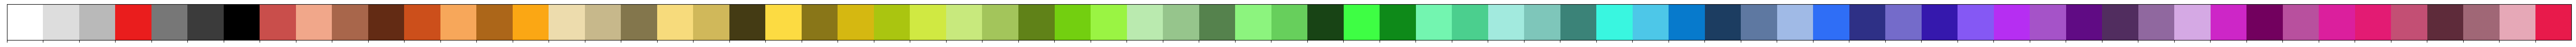

In [ ]:
sns.palplot(uw71coords.sort_values(by=['hue_angle','saturation'],ascending=[True,False]).color_hex.tolist())

In [ ]:
a = all_models[0]
a.rsquared_adj

NameError: name 'all_models' is not defined

In [ ]:
def t_score_plot(target_df, predictor_embedding_df,fname,embed_type='w2v'):
    X  = np.hstack([predictor_embedding_df[['c1','c2','c3']],ratings_pc_df[['c1','c2','c3']]])
    y_1 = target_df.iloc[:,1]
    y_2 = target_df.iloc[:,2]
    y_3 = target_df.iloc[:,3]

    _X = sm.add_constant(X)
    #_Z = sm.add_constant(Z)
    all_models =[]
    all_models.append(sm.OLS(y_1, _X).fit())
    all_models.append(sm.OLS(y_2, _X).fit())
    all_models.append(sm.OLS(y_3, _X).fit())

    plt.figure(figsize=(10, 4 * len(all_models)))
    t_cmap = plt.get_cmap("tab20")

    l = [list((t_cmap.colors[1],) * 3), list((t_cmap.colors[3],) * 3), list((t_cmap.colors[5],) * 3), list((t_cmap.colors[7],) * 3)]
    t_colors = [item for sublist in l for item in sublist]

    for index, this_model in enumerate(all_models):
        ax = plt.subplot(len(all_models), 1, index + 1)

        bar = ax.bar(np.arange(len(this_model.tvalues[1:])), np.abs(this_model.tvalues[1:]), color=t_colors)

        for i, rect in enumerate(bar):
            if this_model.pvalues[i + 1] < 0.001:
                annot = '***'
            elif this_model.pvalues[i + 1] < 0.01:
                annot = '**'
            elif this_model.pvalues[i + 1] < 0.05:
                annot = '*'
            else:
                annot = ''
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height - 0.4, f'{annot}', ha='center', va='bottom', fontsize=40,
                    fontweight='bold')

        ax.set_xticks(np.arange(1, 6, 3))
        ax.set_xticklabels(['word embeddings', 'color-concept \n associations'], fontsize=20, rotation=20)
        ax.set_ylim(0, 11)
        ax.set_ylabel('t-score', fontsize=30)
        ax.set_xlabel('')
        ### get the y ticks
        ax.tick_params(axis='y', labelsize=18)
    
        ax.set_title(f'Regressor t-scores for {fname} judgement component {index+1} using {embed_type} word embeddings \n model R^2 = {np.round(this_model.rsquared_adj,3)}', fontsize=20, pad=10)

    plt.tight_layout()
   
    # plt.savefig('reg1.pdf', bbox_inches='tight')
    plt.savefig(f'../../data/recon_assocs/t_scores_{fname}_{embed_type}.pdf', format='pdf', bbox_inches='tight')
    # plt.show()
    # plt.close()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


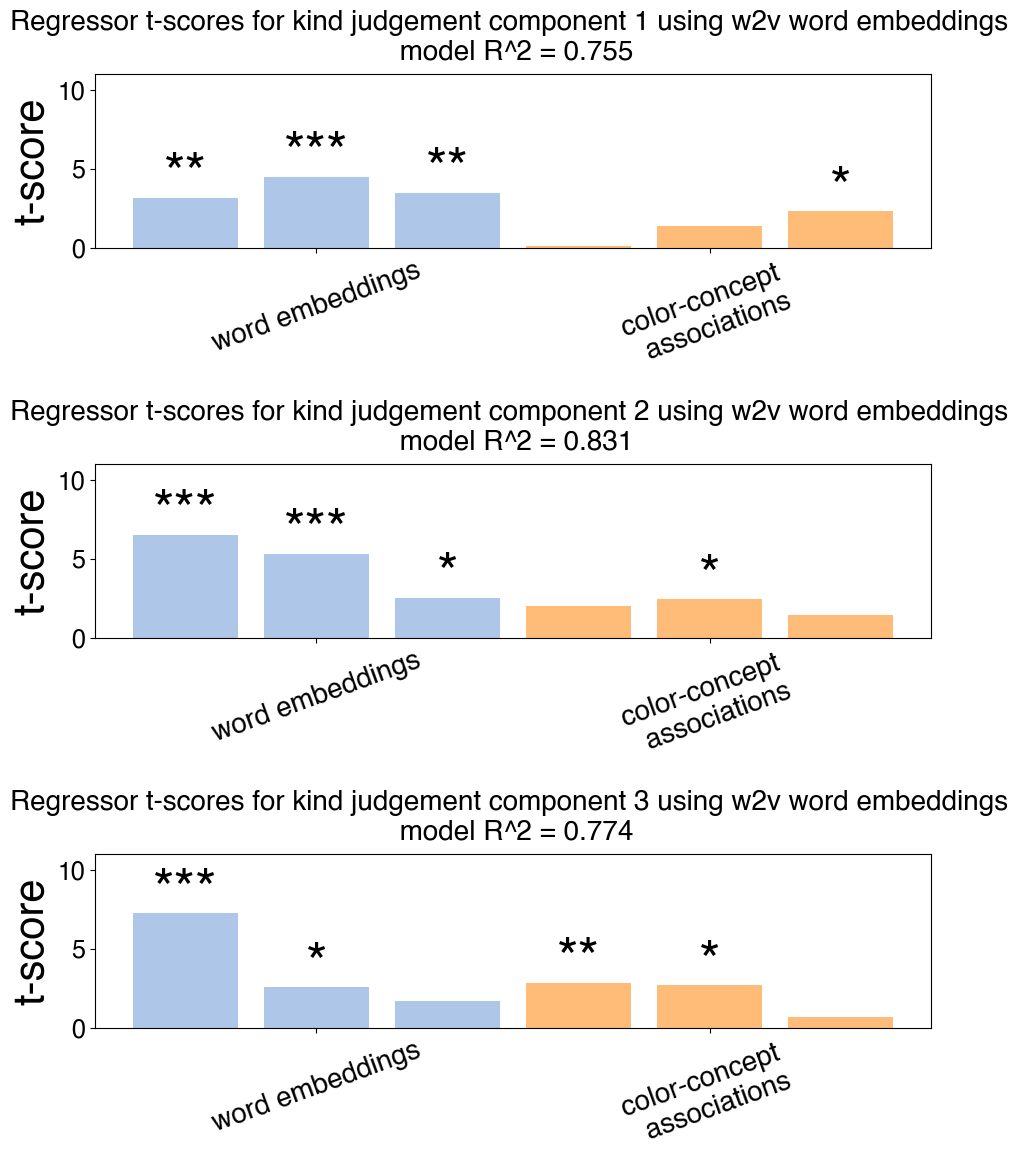

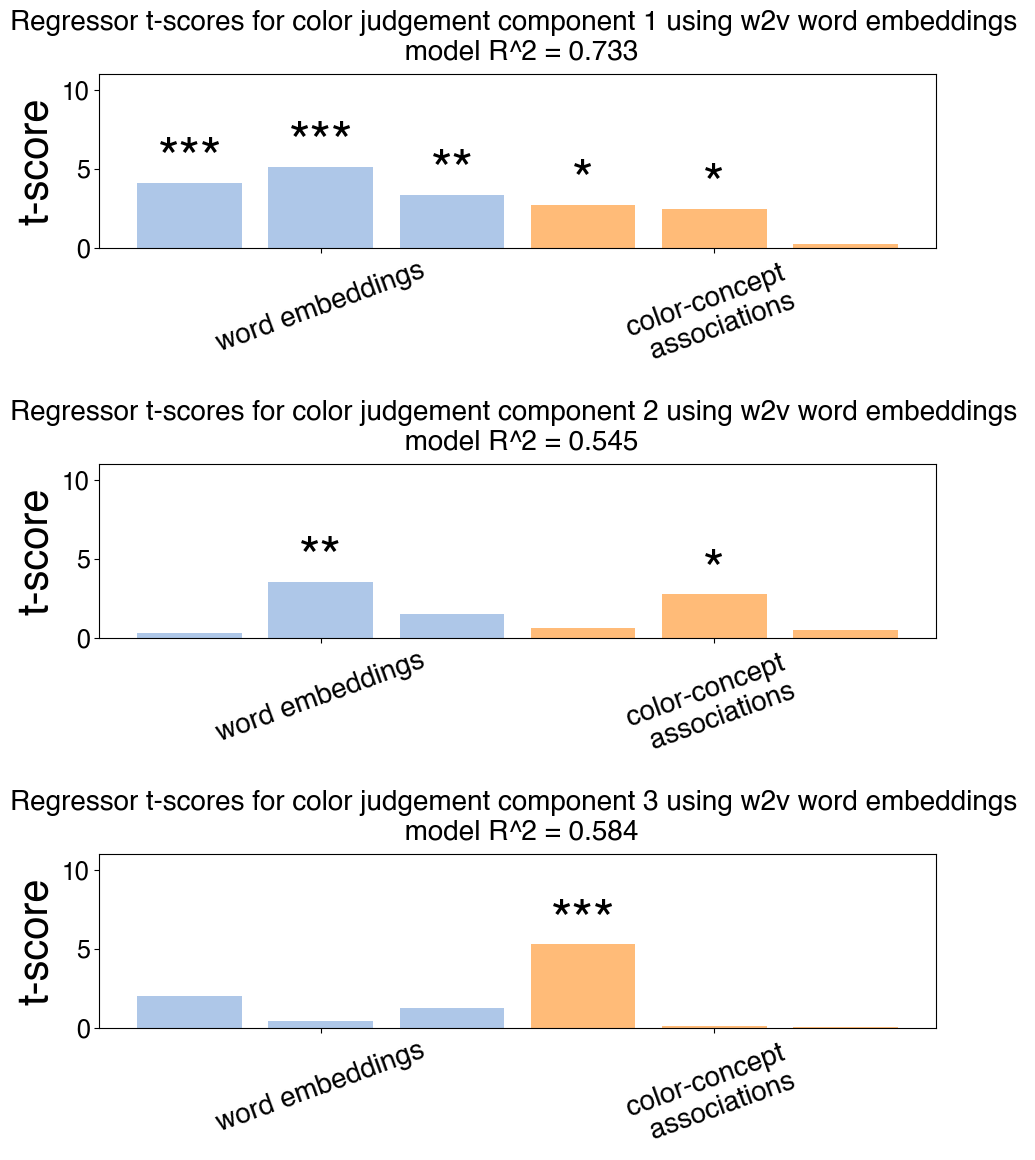

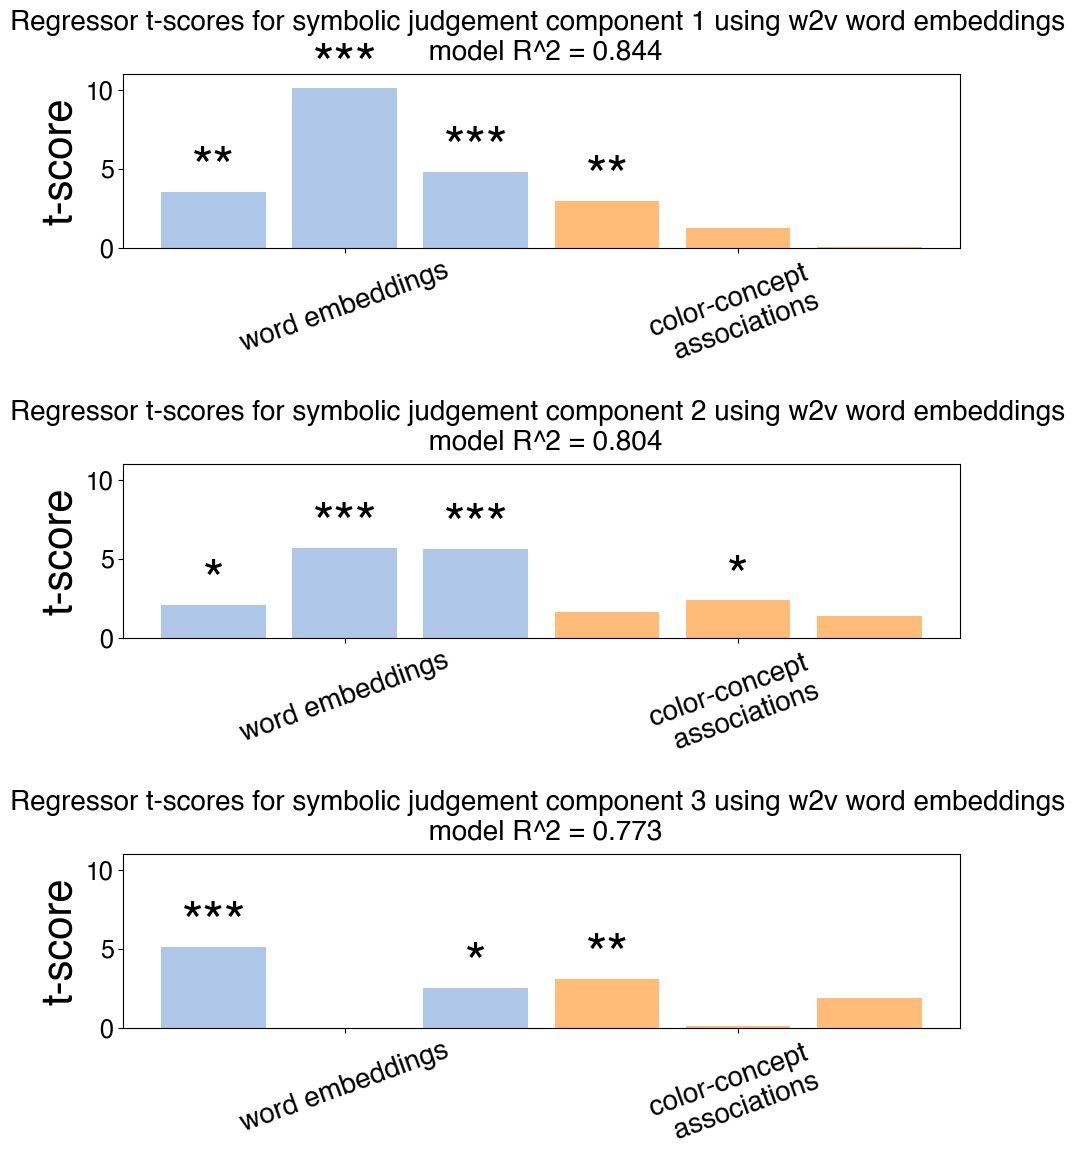

In [ ]:
t_score_plot(kind3d_df,w2v_pc_df,'kind')
t_score_plot(col3d_df,w2v_pc_df,'color')
t_score_plot(sym3d_df,w2v_pc_df,'symbolic')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


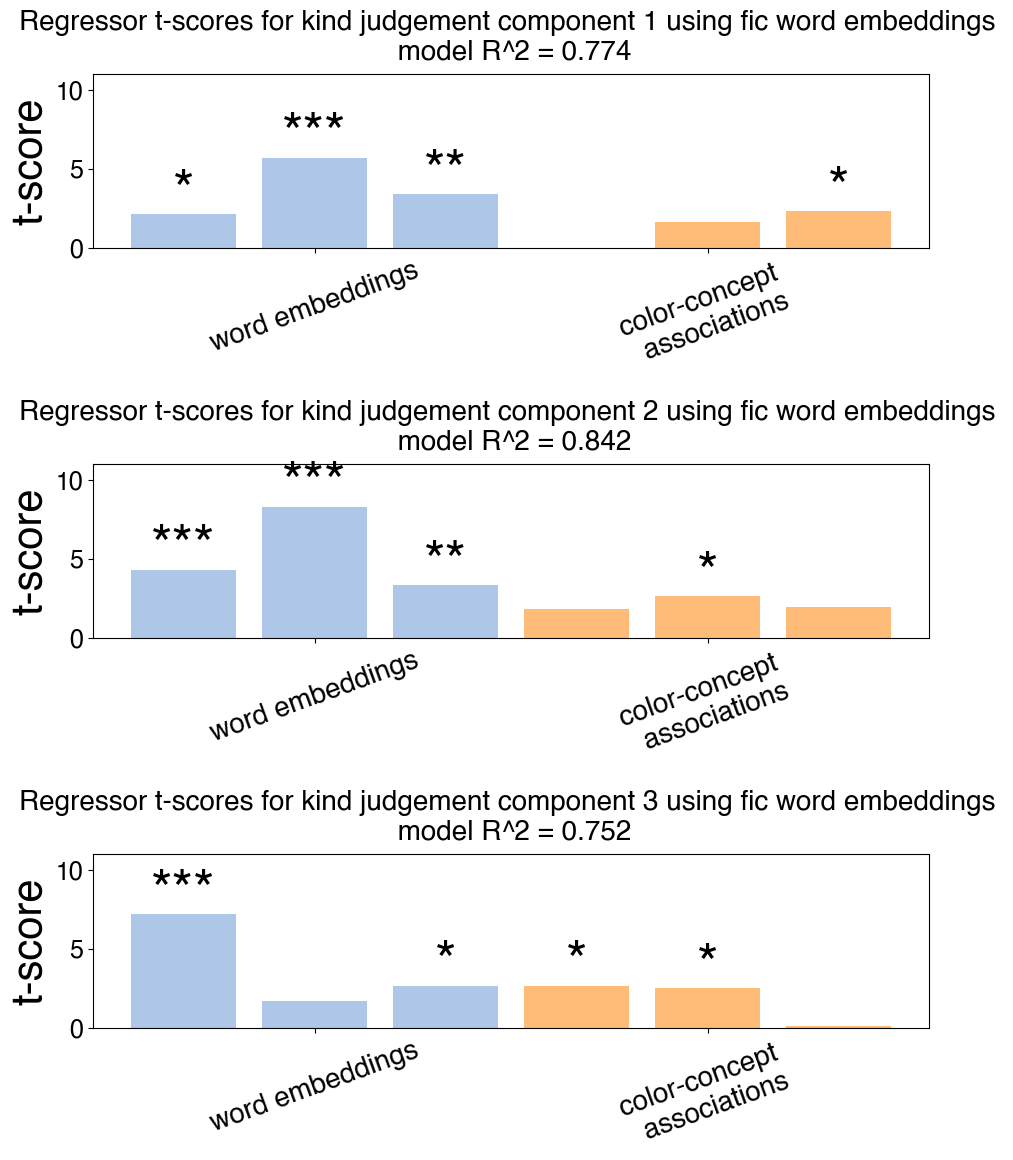

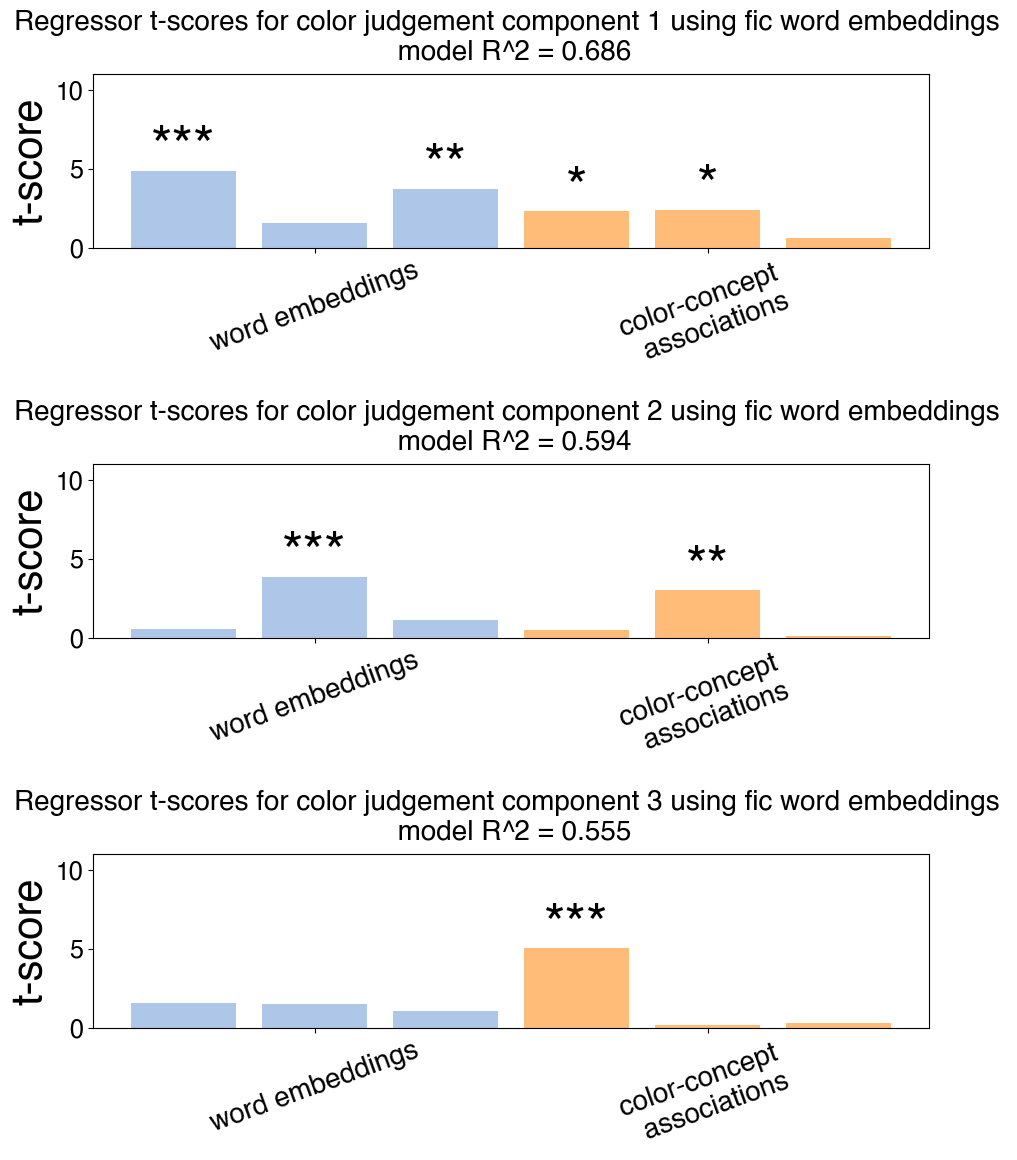

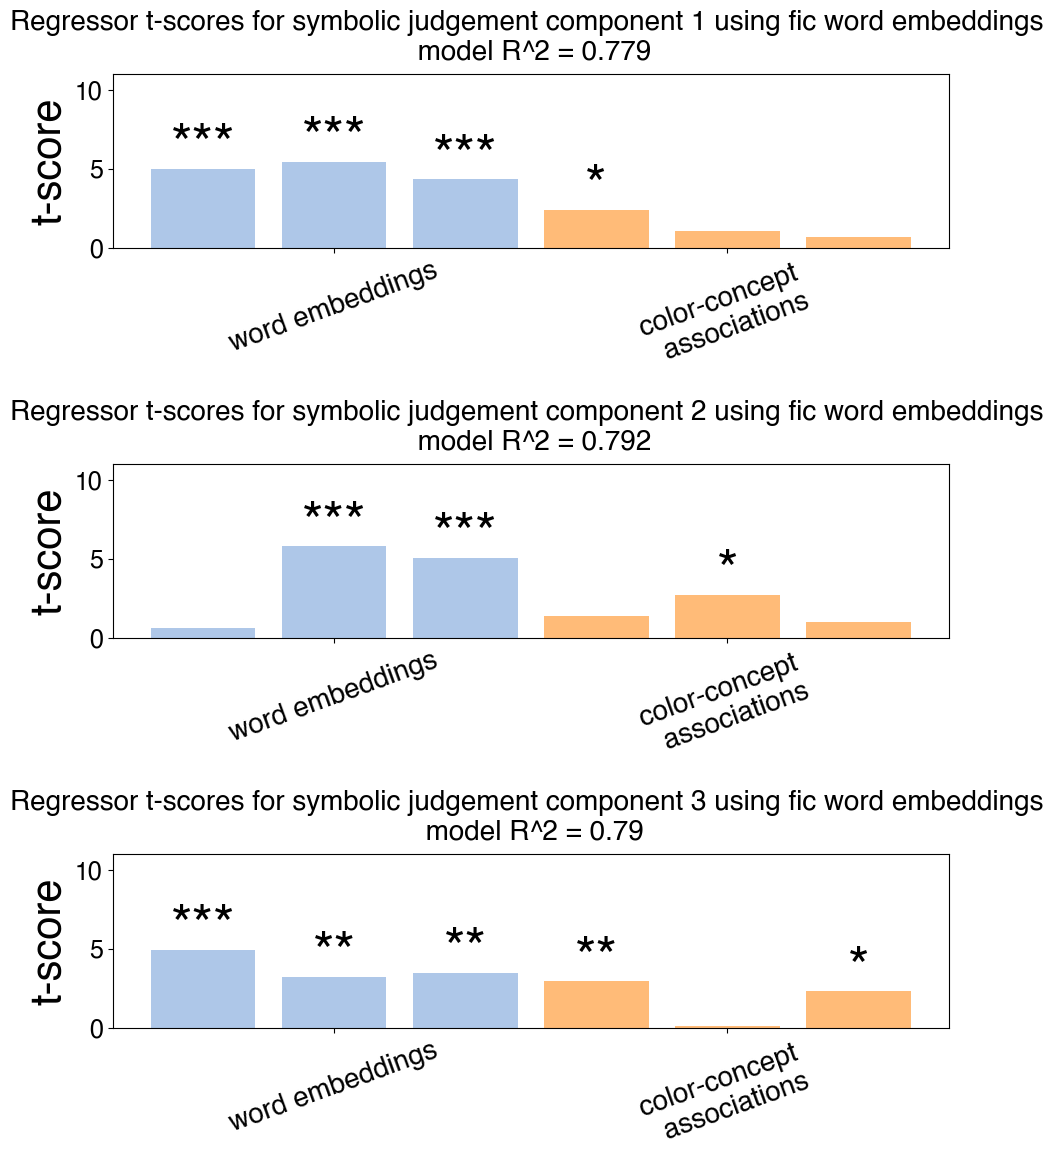

In [ ]:
t_score_plot(kind3d_df,fic_pc_df,'kind',embed_type='fic')
t_score_plot(col3d_df,fic_pc_df,'color',embed_type='fic')
t_score_plot(sym3d_df,fic_pc_df,'symbolic',embed_type='fic')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


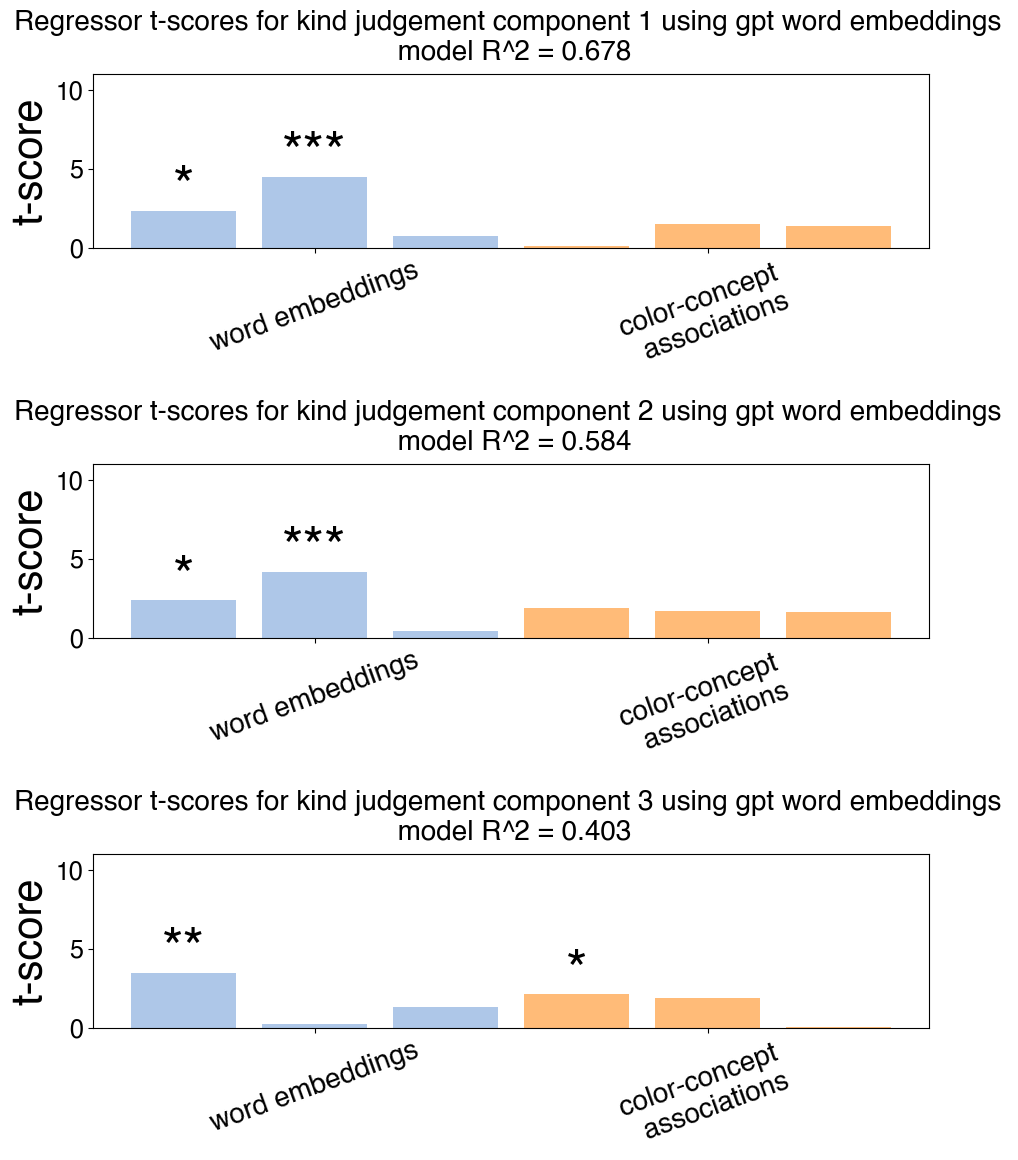

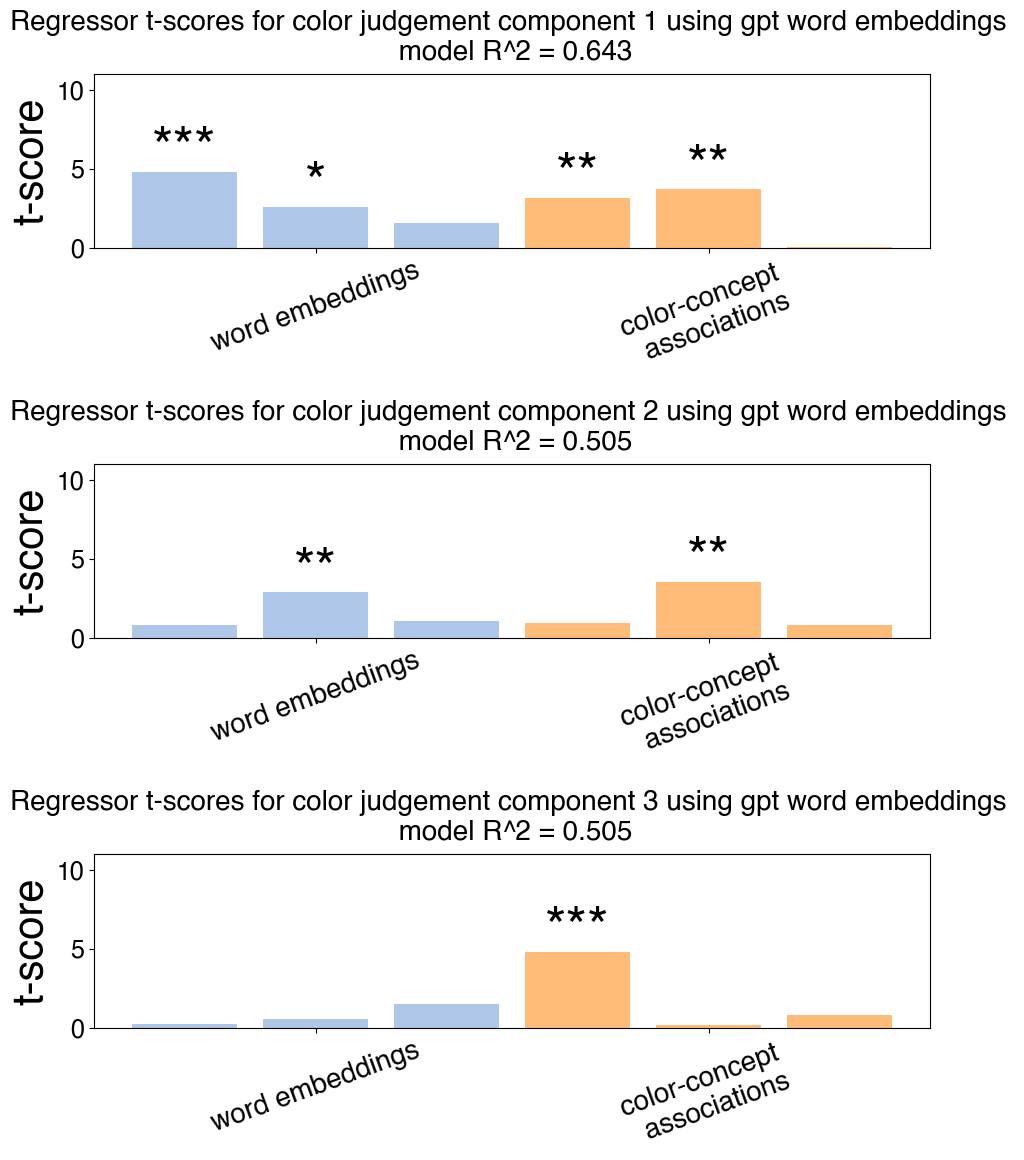

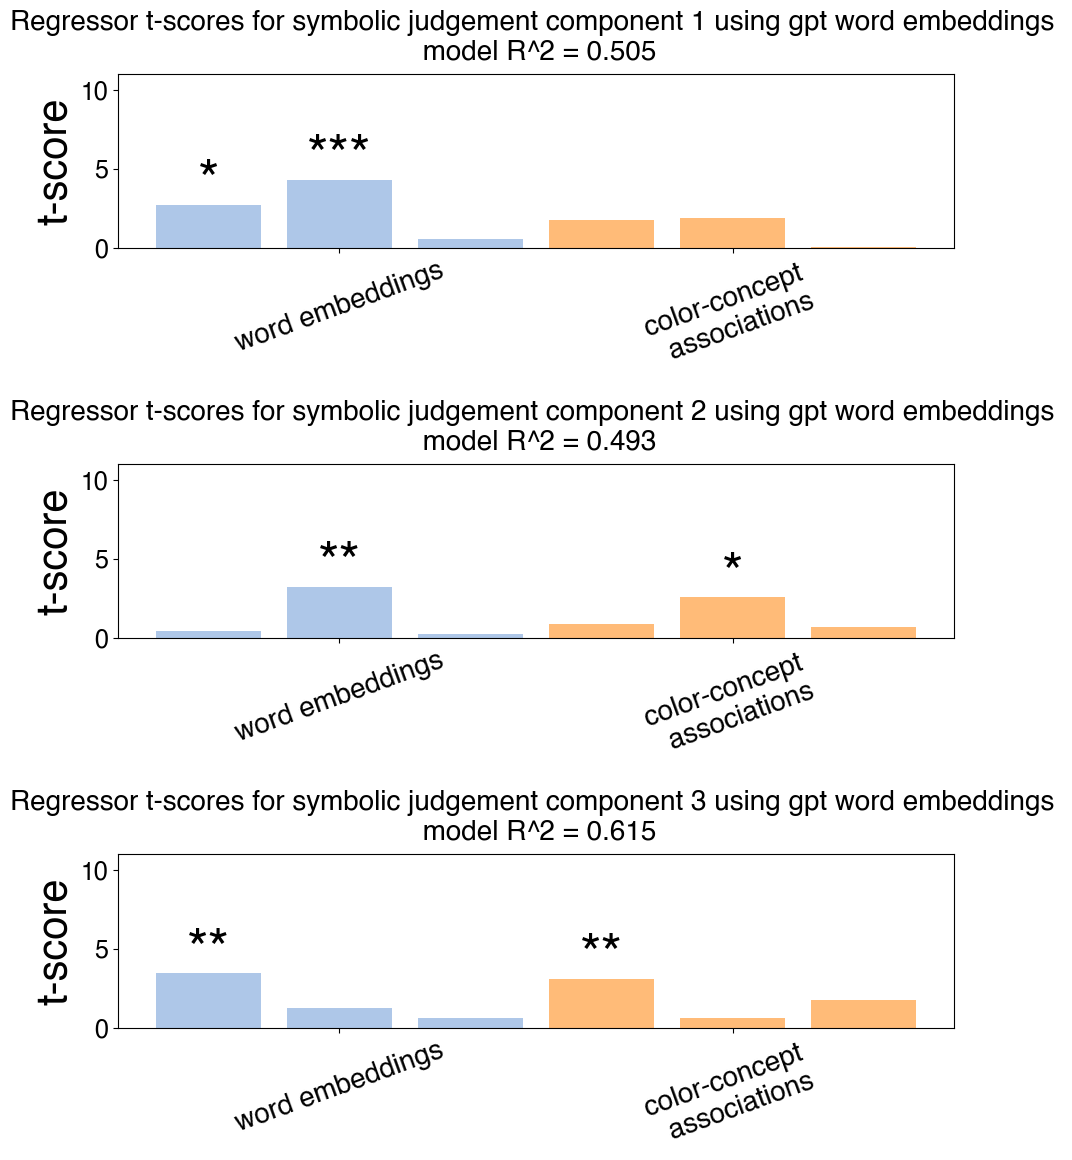

In [ ]:
t_score_plot(kind3d_df,gpt_pc_df,'kind',embed_type='gpt')
t_score_plot(col3d_df,gpt_pc_df,'color',embed_type='gpt')
t_score_plot(sym3d_df,gpt_pc_df,'symbolic',embed_type='gpt')

In [ ]:
cat2color_dict={'emotions':'#D81F33','clothes':'#3e459c','times-of-day':'#7ed0da','scenes':'#05a04a',
                'directions':'#787878','fruits':'#e97924'}

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


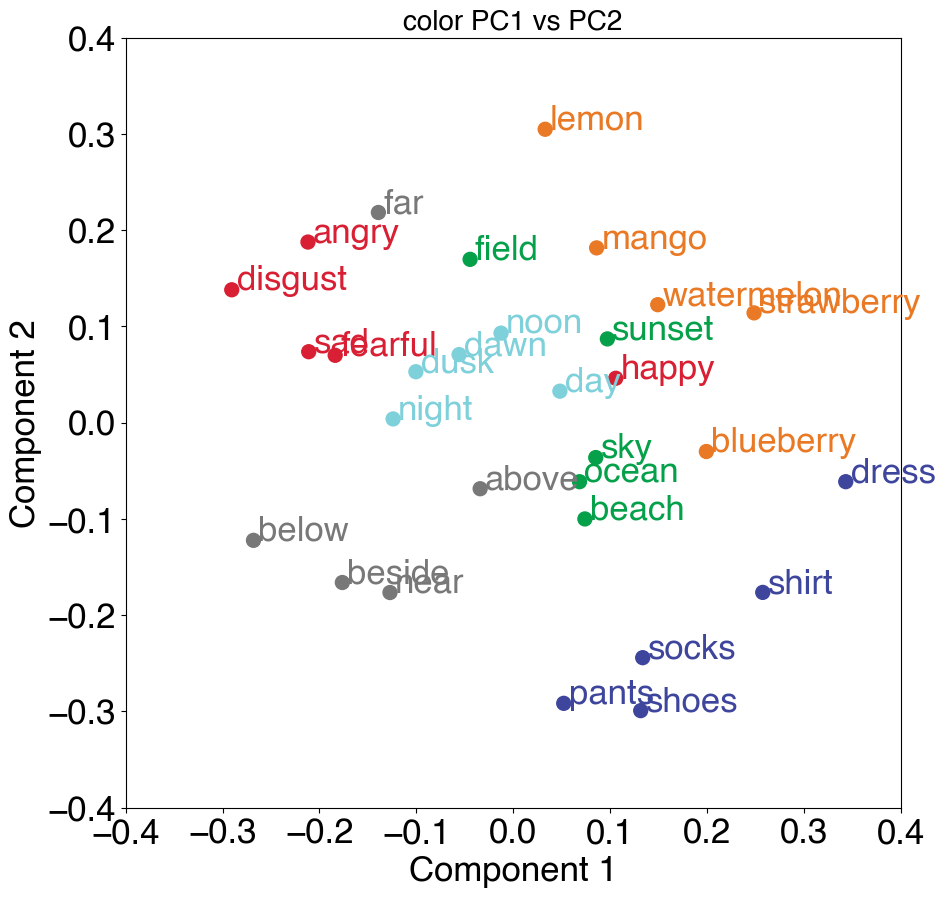

In [ ]:
d = pd.read_csv('../../data/semantic_alignment_data/color_salmon.csv')
d['category'] = d['concept'].map(concept2cat_dict)
d['color'] = d['category'].map(cat2color_dict)
fig= plt.figure(figsize=(10,10))
# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(d['d1'], d['d2'], s=100, c=d['color'])
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (d.d1[i]+0.005,d.d2[i]),fontsize=25, color=d.color[i])
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_ylim(-.4,.4)
ax.set_xlim(-.4,.4)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_title('color PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/color_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


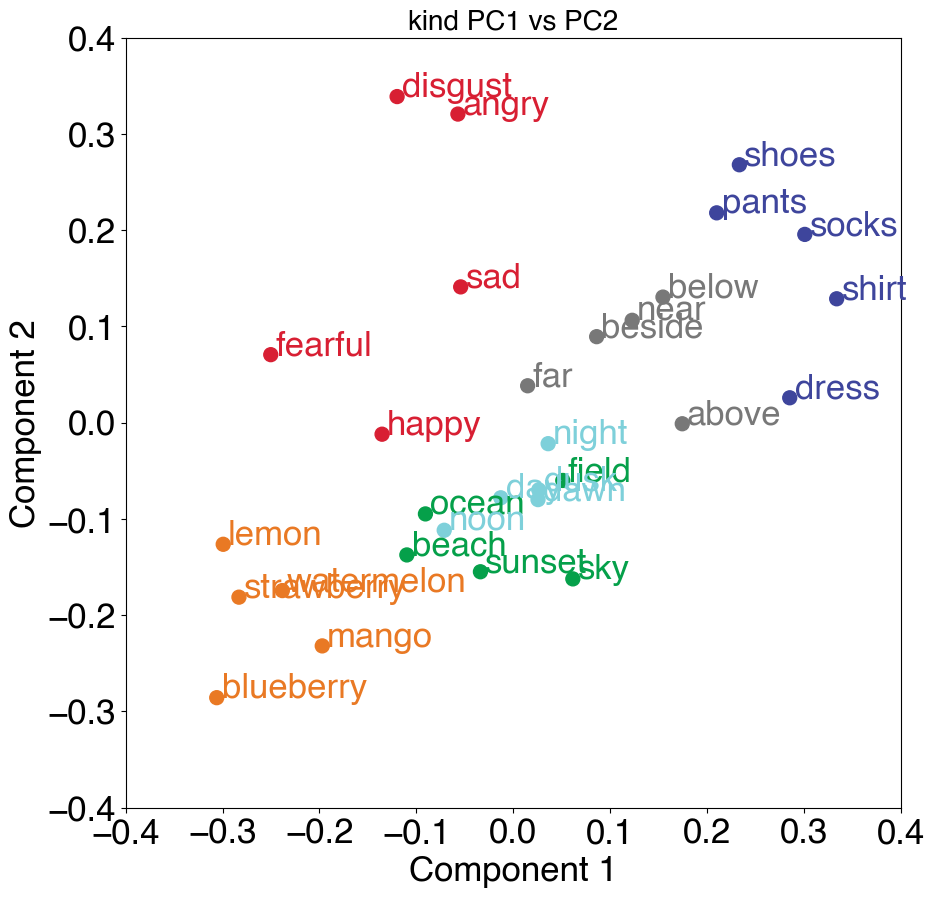

In [ ]:
d = pd.read_csv('../../data/semantic_alignment_data/kind_salmon.csv')
d['category'] = d['concept'].map(concept2cat_dict)
d['color'] = d['category'].map(cat2color_dict)
fig= plt.figure(figsize=(10,10))

# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(d['d1'], d['d2'], s=100, c=d['color'])
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (d.d1[i]+0.005,d.d2[i]),fontsize=25, color=d.color[i])
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_ylim(-.4,.4)
ax.set_xlim(-.4,.4)
ax.set_title('kind PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/kind_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


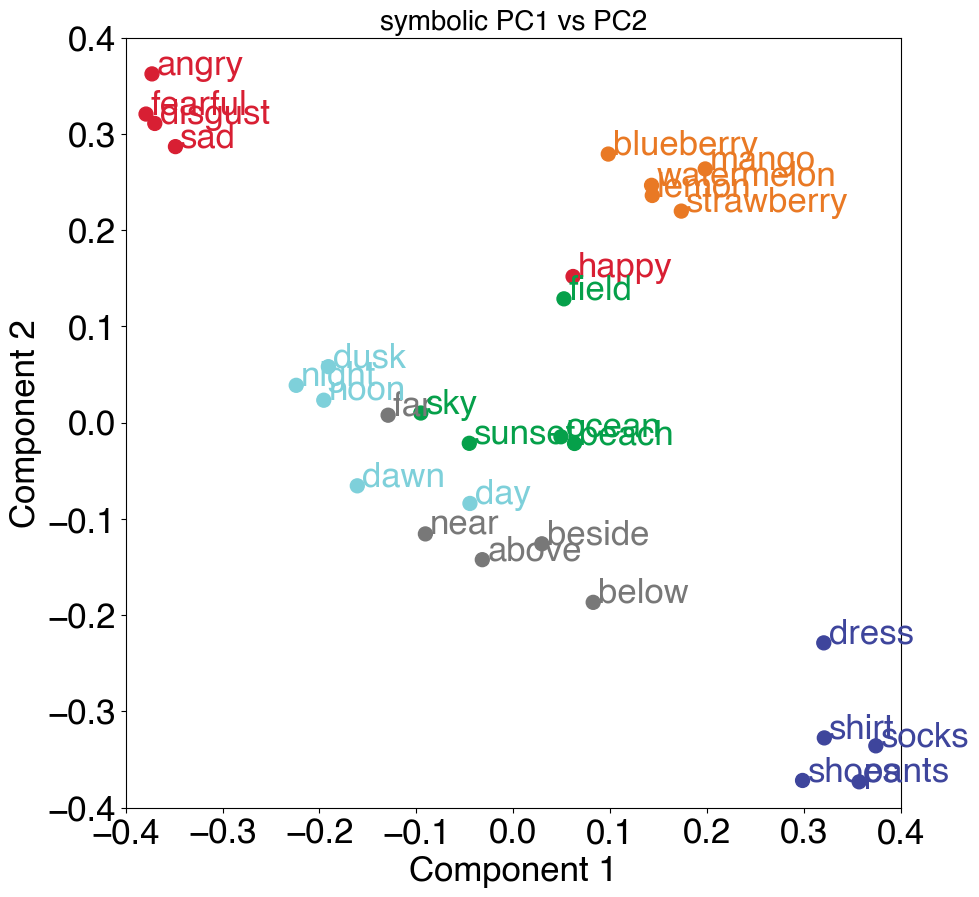

In [ ]:
d = pd.read_csv('../../data/semantic_alignment_data/symbolic_salmon.csv')
d['category'] = d['concept'].map(concept2cat_dict)
d['color'] = d['category'].map(cat2color_dict)
fig= plt.figure(figsize=(10,10))
# ax = plt.axes(projection='3d')
## plot each concept in ratings_pc_df using the first 2 pcs in c1 and c2 in a 2d scatter plot
ax = fig.add_subplot(111)
ax.scatter(d['d1'], d['d2'], s=100, c=d['color'])
for i, txt in enumerate(ratings_pc_df.concepts):
    # ax.annotate(txt, (ratings_pc_df.c1[i],ratings_pc_df.c2[i]),fontsize=20)
    ## shift the text a little bit to the right
    ax.annotate(txt, (d.d1[i]+0.005,d.d2[i]),fontsize=25, color=d.color[i])
ax.set_xlabel('Component 1',fontsize=25)
ax.set_ylabel('Component 2',fontsize=25)
ax.set_ylim(-.4,.4)
ax.set_xlim(-.4,.4)
ax.set_xticklabels(labels=ax.get_xticklabels(),fontsize=25)
ax.set_yticklabels(labels=ax.get_yticklabels(),fontsize=25)
ax.set_title('symbolic PC1 vs PC2',fontsize=20)
plt.savefig('../../data/recon_assocs/symbolic_pc1_pc2_scatter.pdf', bbox_inches='tight')


# ax.view_init(35, 155)
# #sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

# ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
# for i, txt in enumerate(ratings_pc_df['concepts']):
#     ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
# plt.title('color-concept association space', fontsize=25)



In [77]:
### compute the procrustes similarity between the color, kind and symbolic 3d embeddings
from scipy.spatial import procrustes
from scipy.spatial.distance import cdist


m1 = col3d_df[['d1','d2','d3']].values
m2 = kind3d_df[['d1','d2','d3']].values
m3 = sym3d_df[['d1','d2','d3']].values

m1, m2, disparity = procrustes(m1, m2)
print('Disparity between color and kind:', disparity)
print('Correlation between color and kind:', np.sqrt(1-np.sum((m1 - m2)**2, axis=1).mean()))
m1, m3, disparity = procrustes(m1, m3)
print('Disparity between color and symbolic:', disparity)

print('Correlation between color and symbolic:', np.sqrt(1-np.sum((m1 - m3)**2, axis=1).mean()))
m2, m3, disparity = procrustes(m2, m3)
print('Disparity between kind and symbolic:', disparity)
print('Correlation between kind and symbolic:',np.sqrt(1-np.sum((m2 - m3)**2, axis=1).mean()))  
### convert the disparity to a correlation




Disparity between color and kind: 0.5154756345406102
Correlation between color and kind: 0.9913715140393364
Disparity between color and symbolic: 0.4410591207724948
Correlation between color and symbolic: 0.9926217957044785
Disparity between kind and symbolic: 0.2668873862630441
Correlation between kind and symbolic: 0.9955419397449973


0.8576571847958347